In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(-1, '/Users/ponddie/Documents/py/mda/')
from hahelper import *

import pandas as pd, numpy as np
import geopandas as gpd

In [2]:
pd.options.display.max_columns=1000
pd.options.display.max_rows=1000

PATH_COUNT = 'data/data-2019-08.csv'
PATH_RICH = 'data/richtingen.csv'
PATH_SITES = 'data/sites.csv'

## A. Data Cycling

#### 1. Data Count

In [ ]:
total_rows = 0
total_files=0
for file in os.listdir('data/'):
    if file.startswith('data'):
        filepath = os.path.join('data', file)
        df = pd.read_csv(filepath)
        print(file, df.shape)
        total_files+=1
        total_rows += df.shape[0]

data-2024-03.csv (821375, 6)
data-2024-02.csv (768383, 6)
data-2019-08.csv (123147, 6)
data-2023-09.csv (796193, 6)
data-2023-08.csv (815423, 6)
data-2024-01.csv (823363, 6)
data-2019-09.csv (138239, 6)
data-2021-09.csv (155519, 6)
data-2024-11.csv (804763, 6)
data-2024-05.csv (816615, 6)
data-2024-04.csv (794879, 6)
data-2024-10.csv (809495, 6)
data-2021-08.csv (160703, 6)
data-2026-01.csv (863721, 6)
data-2026-03.csv (351505, 6)
data-2024-06.csv (789119, 6)
data-2024-12.csv (830905, 6)
data-2024-07.csv (815423, 6)
data-2026-02.csv (784599, 6)
data-2025-08.csv (855837, 6)
data-2022-01.csv (160703, 6)
data-2020-04.csv (143999, 6)
data-2020-10.csv (148799, 6)
data-2020-11.csv (143999, 6)
data-2020-05.csv (148799, 6)
data-2025-09.csv (823835, 6)
data-2022-02.csv (145151, 6)
data-2020-07.csv (148799, 6)
data-2020-06.csv (143999, 6)
data-2020-12.csv (148799, 6)


In [ ]:
total_files, total_rows

In [ ]:
lmonth = [(f"{y}-{m:02}") for y in range(2019, 2027) for m in range(1, 13) if f"{y}-{m:02}" >= "2019-08" and f"{y}-{m:02}" <= "2026-03"]
len(lmonth)

In [ ]:
for i in lmonth:
    dft = pd.read_csv(f'data/data-{i}.csv', header=None)
    dft.columns=['siteid', 'richting', 'type', 'van', 'tot', 'aantal']
    print(i, f'type: {dft['type'].unique()}')

In [290]:
df1 = pd.read_csv('data/data-2026-03.csv', header=None)
df1.columns=['siteid', 'richting', 'type', 'van', 'tot', 'aantal']
df1.shape

(351506, 6)

In [291]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351506 entries, 0 to 351505
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   siteid    351506 non-null  int64  
 1   richting  351506 non-null  object 
 2   type      351506 non-null  object 
 3   van       351506 non-null  object 
 4   tot       351506 non-null  object 
 5   aantal    349466 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 16.1+ MB


In [292]:
df1.head()

,siteid,richting,type,van,tot,aantal
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0


In [293]:
df1.describe()

,siteid,aantal
count,351506.000000,349466.000000
mean,74.746787,3.307054
std,43.689322,8.681127
min,1.000000,0.000000
25%,37.000000,0.000000
50%,74.000000,0.000000
75%,112.000000,3.000000
max,152.000000,266.000000


In [294]:
df1['type'].unique()

array(['FIETSERS'], dtype=object)

In [295]:
df1['van'] = pd.to_datetime(df1['van'])
df1['tot'] = pd.to_datetime(df1['tot'])
df1['duration'] = (df1['tot'] - df1['van']).dt.total_seconds() / 60
df1['tod'] = df1['van'].apply(time_of_day)
df1['date'] = df1['van'].apply(lambda x: str(x)[:10])
df1['hour'] = df1['van'].dt.hour
df1['dow'] = df1['van'].dt.day_name()
df1['weekend'] = df1['dow'].isin(['Saturday', 'Sunday']).astype(int)

df1

,siteid,richting,type,van,tot,aantal,duration,tod,date,hour,dow,weekend
0,1,IN,FIETSERS,2026-03-01 00:00:00,2026-03-01 00:15:00,0.0,15.0,night,2026-03-01,0,Sunday,1
1,1,IN,FIETSERS,2026-03-01 00:15:00,2026-03-01 00:30:00,0.0,15.0,night,2026-03-01,0,Sunday,1
2,1,IN,FIETSERS,2026-03-01 00:30:00,2026-03-01 00:45:00,0.0,15.0,night,2026-03-01,0,Sunday,1
3,1,IN,FIETSERS,2026-03-01 00:45:00,2026-03-01 01:00:00,0.0,15.0,night,2026-03-01,0,Sunday,1
4,1,IN,FIETSERS,2026-03-01 01:00:00,2026-03-01 01:15:00,1.0,15.0,night,2026-03-01,1,Sunday,1
...,...,...,...,...,...,...,...,...,...,...,...,...
351501,152,OUT,FIETSERS,2026-03-13 03:45:00,2026-03-13 04:00:00,0.0,15.0,night,2026-03-13,3,Friday,0
351502,152,OUT,FIETSERS,2026-03-13 04:00:00,2026-03-13 04:15:00,0.0,15.0,night,2026-03-13,4,Friday,0
351503,152,OUT,FIETSERS,2026-03-13 04:15:00,2026-03-13 04:30:00,0.0,15.0,night,2026-03-13,4,Friday,0
351504,152,OUT,FIETSERS,2026-03-13 04:30:00,2026-03-13 04:45:00,0.0,15.0,night,2026-03-13,4,Friday,0


In [296]:
df1.query('siteid == 1 and richting == "IN" and date == @pd.to_datetime("2019-08-01").date()')['van'].nunique()

0

In [297]:
df2 = df1.groupby(['siteid', 'richting', 'type', 'tod', 'hour', 'dow', 'weekend', 'date']).agg({'aantal':'sum'}).reset_index()
df2.head()

,siteid,richting,type,tod,hour,dow,weekend,date,aantal
0,1,IN,FIETSERS,afternoon,12,Friday,0,2026-03-06,14.0
1,1,IN,FIETSERS,afternoon,12,Monday,0,2026-03-02,12.0
2,1,IN,FIETSERS,afternoon,12,Monday,0,2026-03-09,13.0
3,1,IN,FIETSERS,afternoon,12,Saturday,1,2026-03-07,10.0
4,1,IN,FIETSERS,afternoon,12,Sunday,1,2026-03-01,10.0


In [298]:
df2.describe()

,siteid,hour,weekend,aantal
count,87974.000000,87974.000000,87974.000000,87974.00000
mean,74.741401,11.392070,0.240776,13.13687
std,43.686589,6.963249,0.427557,31.09829
min,1.000000,0.000000,0.000000,0.00000
25%,37.000000,5.000000,0.000000,0.00000
50%,74.000000,11.000000,0.000000,2.00000
75%,112.000000,17.000000,0.000000,13.00000
max,152.000000,23.000000,1.000000,575.00000


In [302]:
df2.shape[0]

87974

In [303]:
df2[df2['aantal']>250].shape[0]/df2.shape[0]

0.0026826107713642665

#### 2. Richtingen

In [3]:
df_rich = pd.read_csv('data/richtingen.csv', header=None)
df_rich.columns=['siteid', 'richting', 'naam']
df_rich.shape

(305, 3)

In [4]:
df_rich.head()

,siteid,richting,naam
0,1,IN,Machelen Cyclists rich. Brucargo
1,1,OUT,Machelen Cyclists richting Machelen
2,2,IN,Brasschaat 2 Fietsers rich Merksem
3,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
4,3,IN,Brasschaat 1 Fietsers rich Merksem


In [5]:
df_rich['from'] = df_rich['naam'].apply(lambda x: x.split()[0])
df_rich['to'] = df_rich['naam'].apply(lambda x: x.split()[-1])

In [182]:
df_rich[['from','to']].drop_duplicates().tail(20)

,from,to
284,YTH17062596,IN
285,YTH17062596,OUT
286,Overijse,UIT
287,Overijse,IN]
288,Overijse,OUT]
289,Overijse,Ijsebos]
290,Test,IN
291,TEST,IN
292,TEST,UIT
294,Overijse,Nieuwland]


In [278]:
df_rich.head(1)

,siteid,richting,naam,from,to
0,1,IN,Machelen Cyclists rich. Brucargo,Machelen,Brucargo


In [280]:
df_rich.query('siteid==1')

,siteid,richting,naam,from,to
0,1,IN,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
1,1,OUT,Machelen Cyclists richting Machelen,Machelen,Machelen
240,1,IN/OUT,Machelen [Debug],Machelen,[Debug]


In [279]:
df_rich['siteid'].value_counts()

siteid
1      3
102    3
34     3
7      3
110    2
105    2
106    2
107    2
108    2
109    2
71     2
72     2
73     2
74     2
75     2
76     2
103    2
104    2
101    2
100    2
112    2
77     2
64     2
65     2
66     2
67     2
68     2
69     2
70     2
91     2
99     2
92     2
93     2
94     2
95     2
96     2
97     2
98     2
111    2
113    2
89     2
114    2
134    2
135    2
136    2
137    2
138    2
139    2
140    2
143    2
146    2
147    2
142    2
148    2
149    2
150    2
151    2
133    2
132    2
131    2
121    2
115    2
116    2
117    2
118    2
119    2
120    2
122    2
129    2
123    2
125    2
126    2
127    2
128    2
124    2
90     2
88     2
2      2
87     2
32     2
33     2
35     2
36     2
37     2
38     2
144    2
145    2
8      2
9      2
11     2
12     2
13     2
14     2
15     2
31     2
30     2
29     2
20     2
3      2
4      2
5      2
6      2
10     2
19     2
21     2
28     2
22     2
23     2
24     2
25     2
26 

In [183]:
df_rich.query('`from`=="YTH17062596"')

,siteid,richting,naam,from,to
284,143,IN,YTH17062596 Cyclists IN,YTH17062596,IN
285,143,OUT,YTH17062596 Cyclists OUT,YTH17062596,OUT


#### 3. Sites

In [6]:
df_sites = pd.read_csv('data/sites.csv', header=None)
df_sites.columns=['siteid', 'sitenr', 'long', 'lat', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van']
df_sites.shape

(151, 11)

In [8]:
df_sites['siteid'].nunique()

151

In [185]:
df_sites['domein'].value_counts()

domein
Vlaamse Overheid A. Wegen enVerkeer     142
Vlaamse Overheid A. Wegen en Verkeer      8
Kortrijk Fietst                           1
Name: count, dtype: int64

In [186]:
df_sites.head()

,siteid,sitenr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22


In [187]:
df_sites.describe()

,siteid,sitenr,long,lat,interval
count,151.000000,1.510000e+02,151.000000,151.000000,151.000000
mean,76.145695,2.655954e+08,4.364879,51.010527,14.801325
std,43.951245,7.575055e+07,0.810268,0.154309,4.578238
min,1.000000,1.000389e+08,2.742890,50.751280,0.000000
25%,38.500000,3.000235e+08,3.768264,50.886897,15.000000
50%,76.000000,3.000256e+08,4.471690,50.990394,15.000000
75%,113.500000,3.000273e+08,4.937732,51.134365,15.000000
max,152.000000,3.000621e+08,5.797260,51.357520,60.000000


In [188]:
df_sites['wegnr'].apply(lambda x: str(x)[0]).unique()

array(['T', 'N', 'R', 'A', 'n'], dtype=object)

In [189]:
df_sites[['siteid','long','lat','naam']].to_csv('ggplot.csv', index=False)

In [190]:
df_sites['datum_van'].min(), df_sites['datum_van'].max()

('2019-08-22', '2025-10-31')

In [191]:
df_rich[['siteid','from']].drop_duplicates()

,siteid,from
0,1,Machelen
2,2,Brasschaat
4,3,Brasschaat
6,4,Balen
8,5,Balen
10,6,Evergem
11,10,Aalst_2
12,19,Aalst
13,20,Brugge
15,21,Bilzen


In [192]:
df_rich['siteid'].nunique(), df_sites['siteid'].nunique(), df_sites['sitenr'].nunique()

(151, 151, 151)

#### 4. Combine

In [193]:
dfx = df2.merge(df_rich, on=['siteid','richting'])
dfx.shape

(30790, 12)

In [194]:
dfx.head()

,siteid,richting,type,tod,hour,dow,weekend,date,aantal,naam,from,to
0,1,IN,FIETSERS,afternoon,12,Friday,0,2019-08-02,8.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
1,1,IN,FIETSERS,afternoon,12,Friday,0,2019-08-09,4.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
2,1,IN,FIETSERS,afternoon,12,Friday,0,2019-08-16,22.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
3,1,IN,FIETSERS,afternoon,12,Friday,0,2019-08-23,9.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
4,1,IN,FIETSERS,afternoon,12,Friday,0,2019-08-30,10.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo


In [195]:
dfx.query("siteid==1 and `date` == '2019-08-01'")

,siteid,richting,type,tod,hour,dow,weekend,date,aantal,naam,from,to
18,1,IN,FIETSERS,afternoon,12,Thursday,0,2019-08-01,4.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
49,1,IN,FIETSERS,afternoon,13,Thursday,0,2019-08-01,11.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
80,1,IN,FIETSERS,afternoon,14,Thursday,0,2019-08-01,10.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
111,1,IN,FIETSERS,afternoon,15,Thursday,0,2019-08-01,19.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
142,1,IN,FIETSERS,afternoon,16,Thursday,0,2019-08-01,15.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
173,1,IN,FIETSERS,afternoon,17,Thursday,0,2019-08-01,22.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
204,1,IN,FIETSERS,evening,18,Thursday,0,2019-08-01,19.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
235,1,IN,FIETSERS,evening,19,Thursday,0,2019-08-01,14.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
266,1,IN,FIETSERS,evening,20,Thursday,0,2019-08-01,15.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo
297,1,IN,FIETSERS,evening,21,Thursday,0,2019-08-01,3.0,Machelen Cyclists rich. Brucargo,Machelen,Brucargo


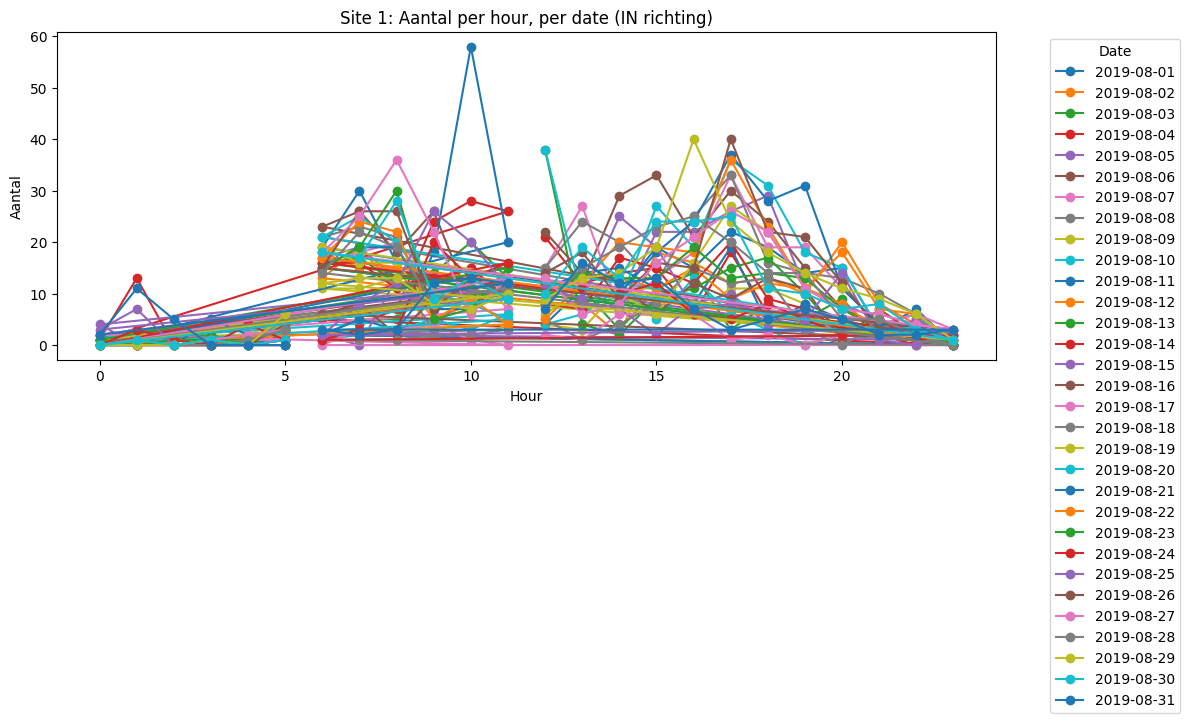

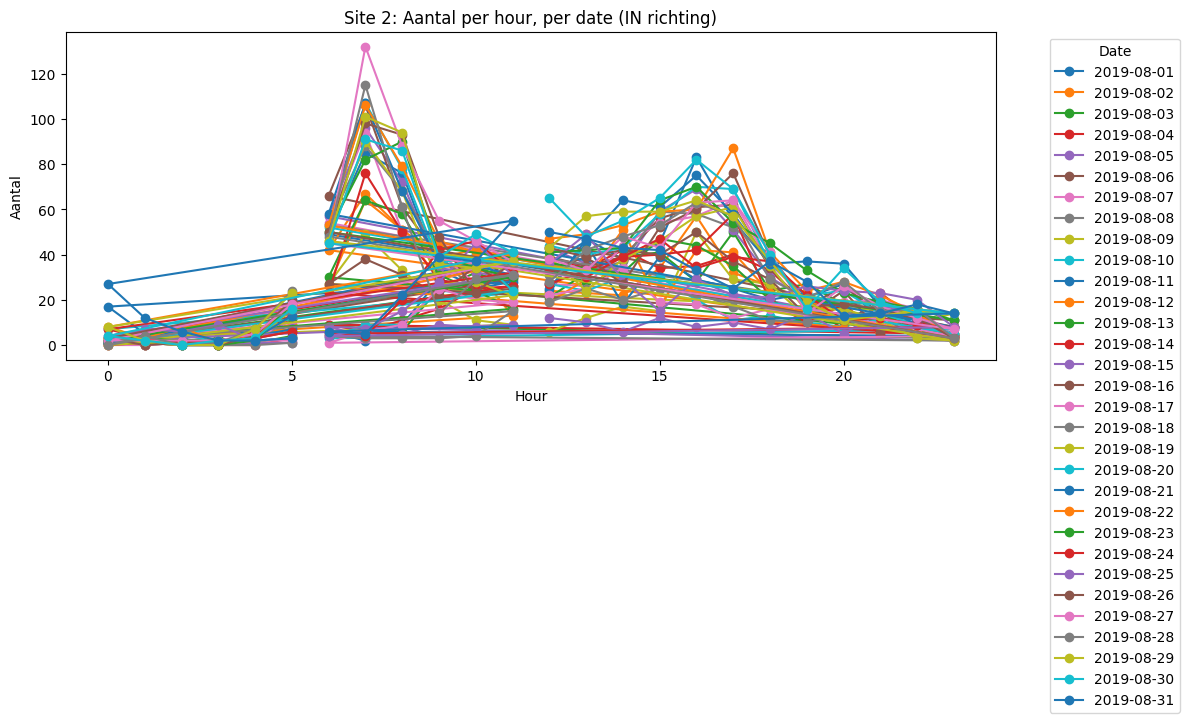

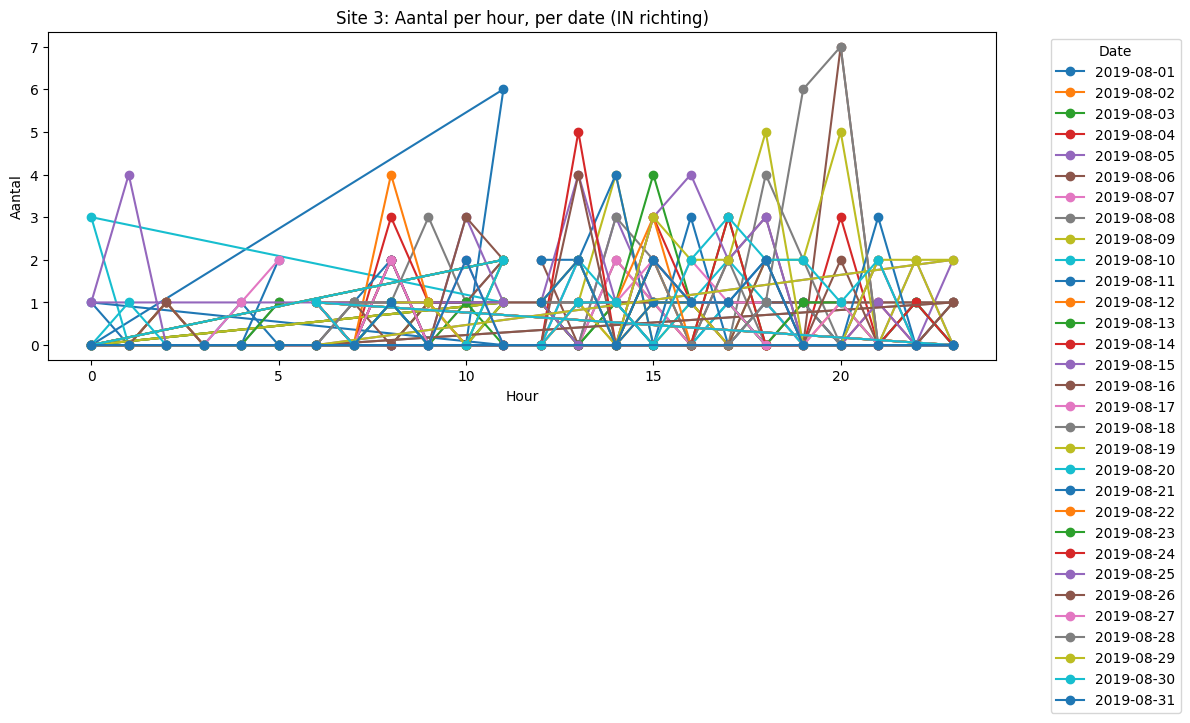

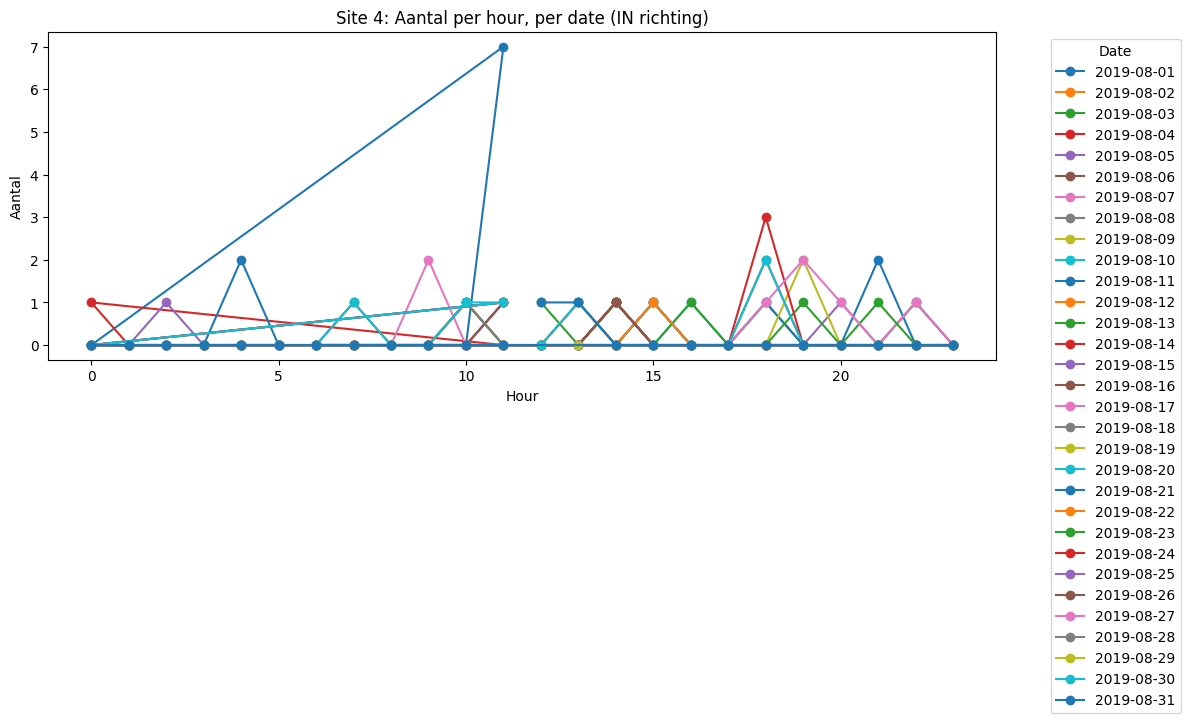

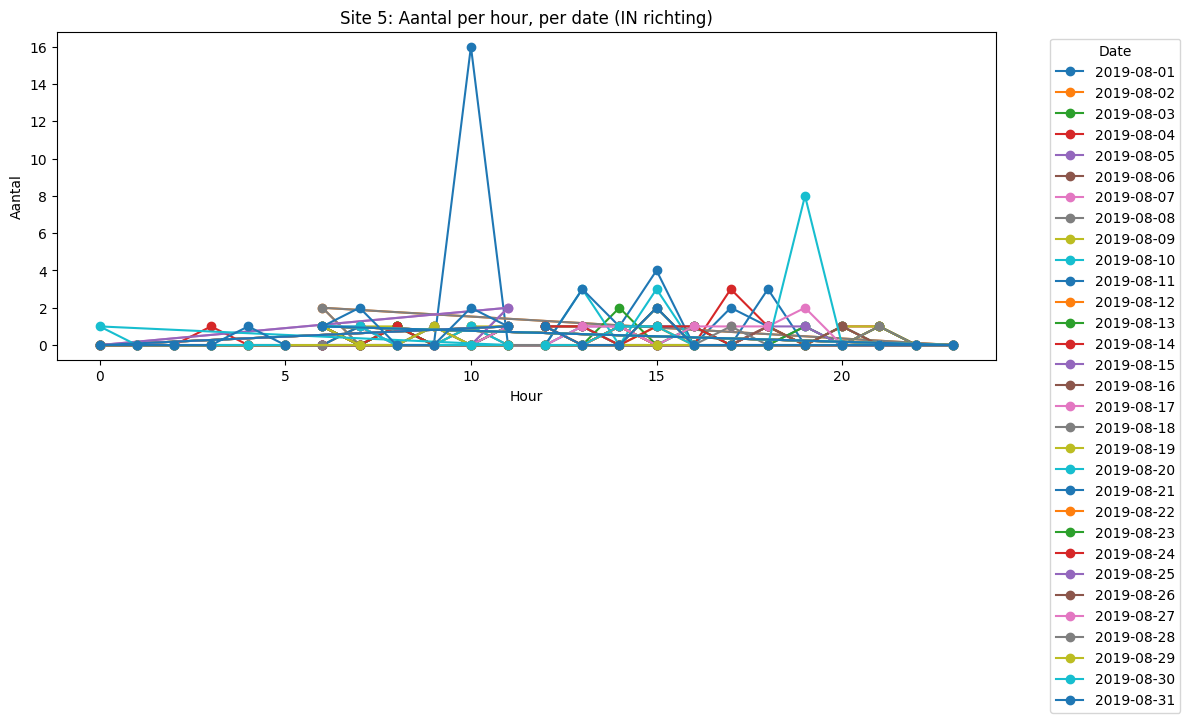

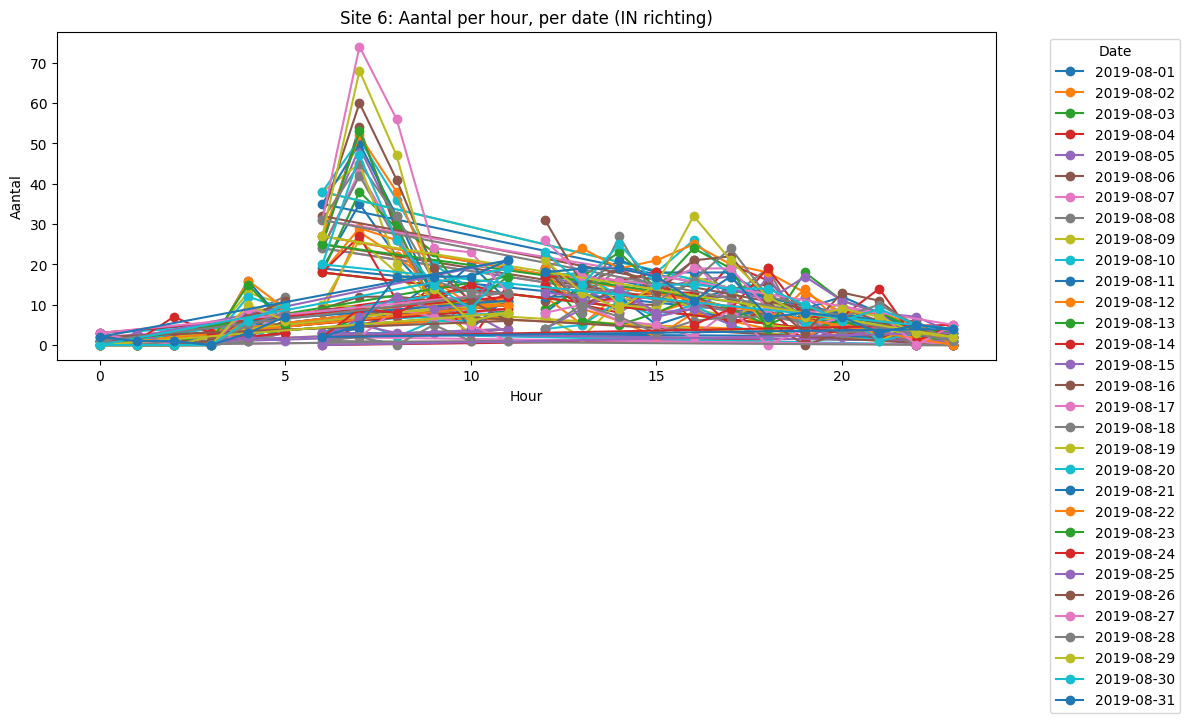

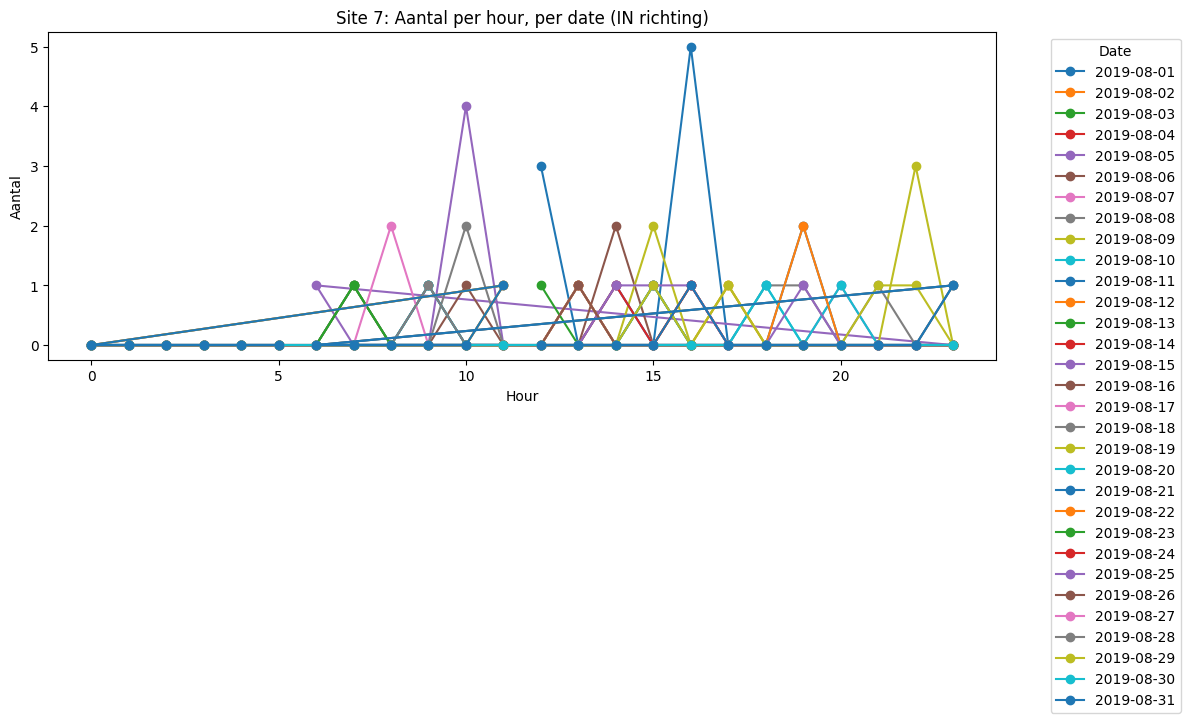

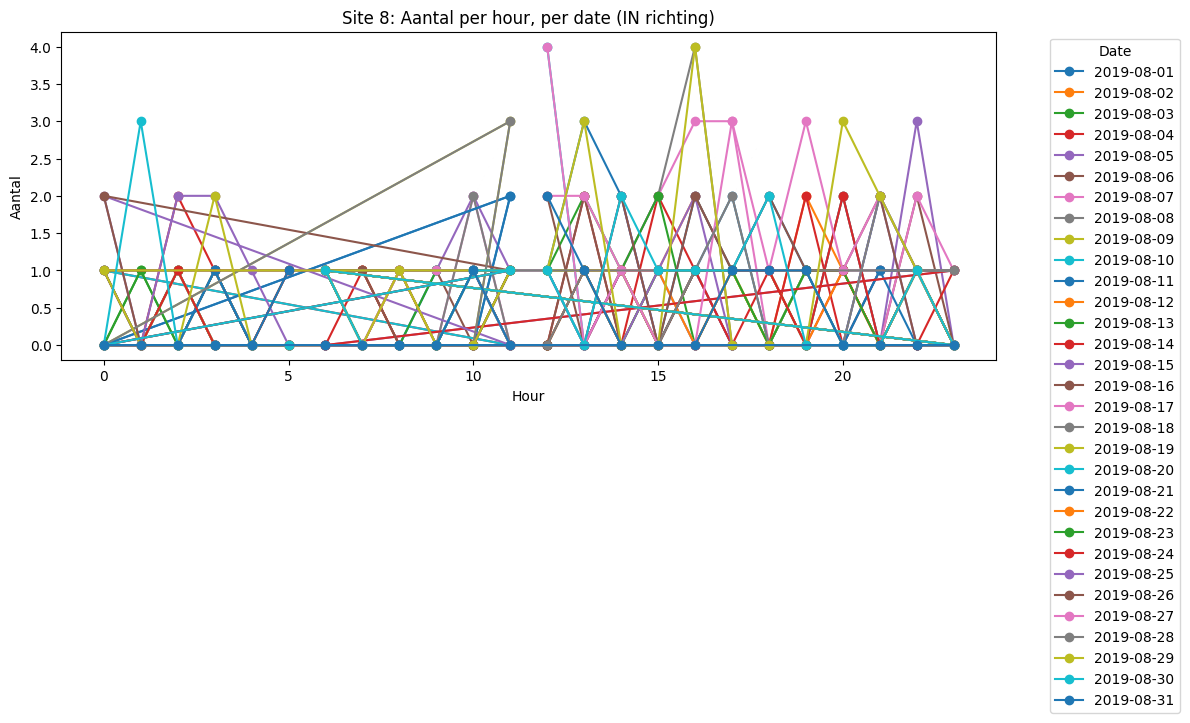

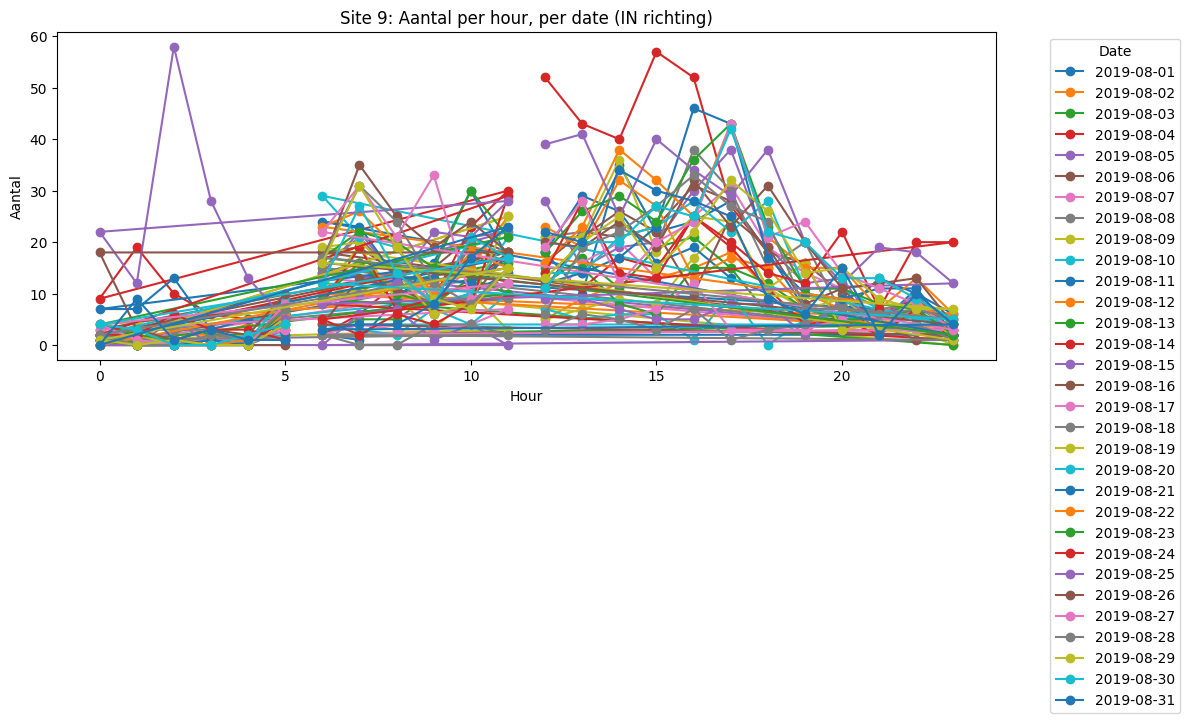

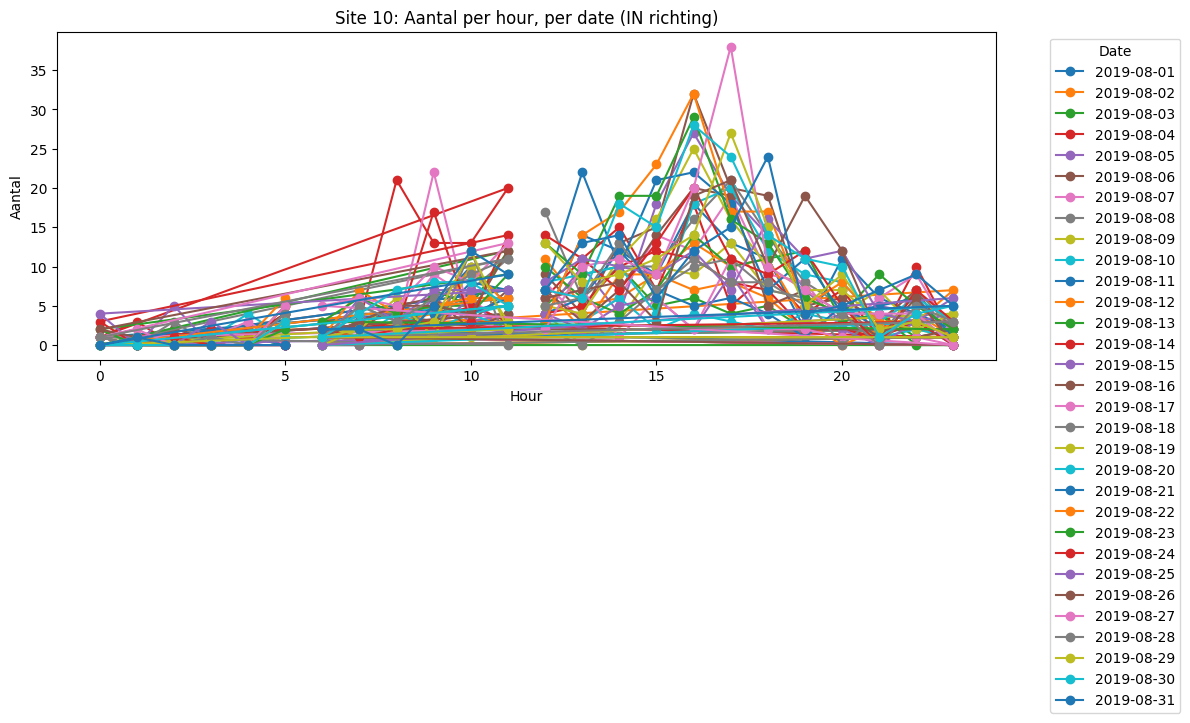

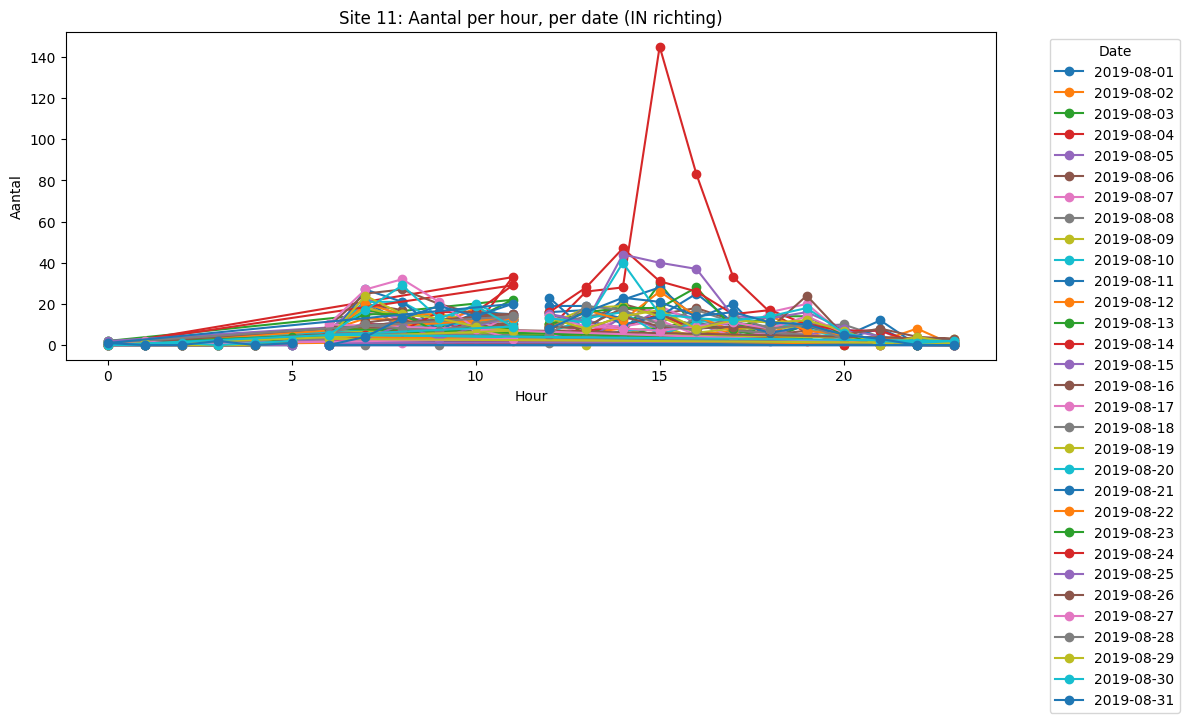

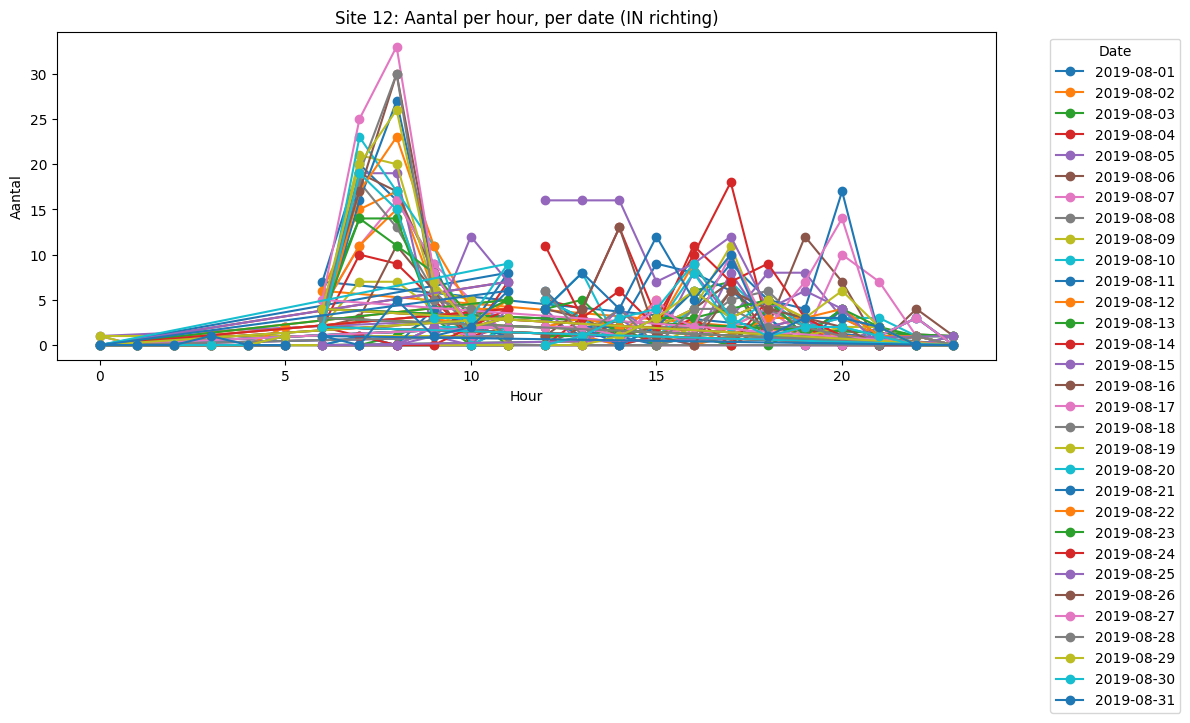

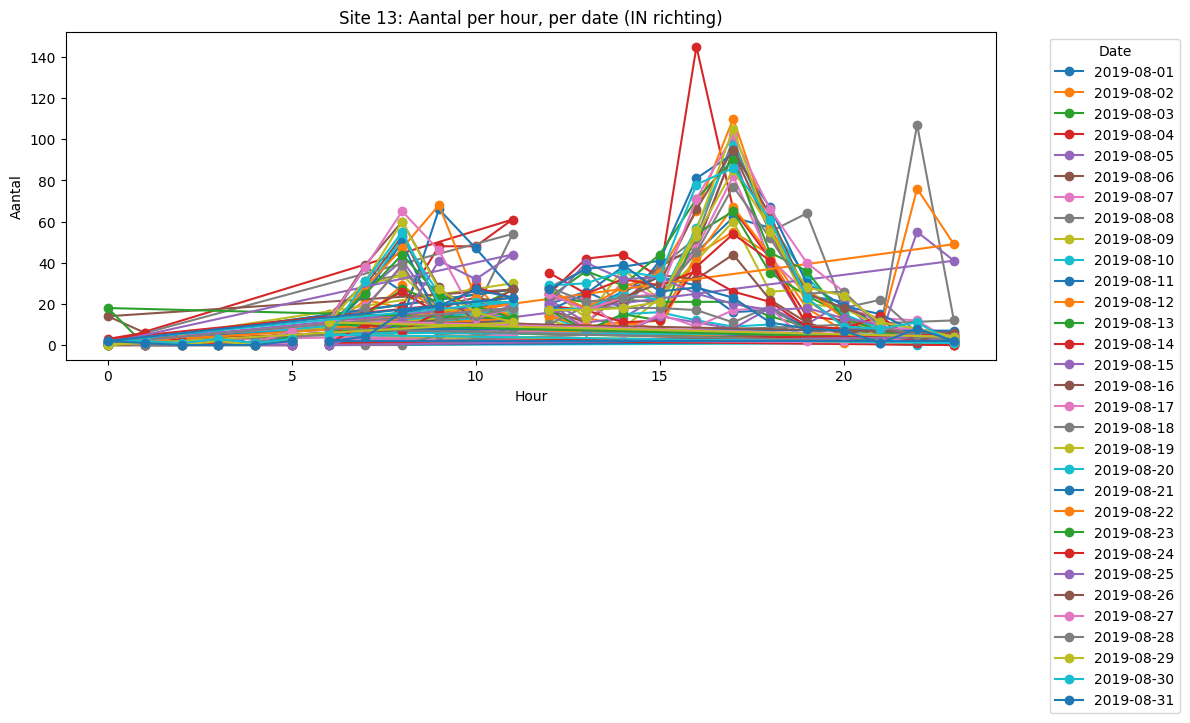

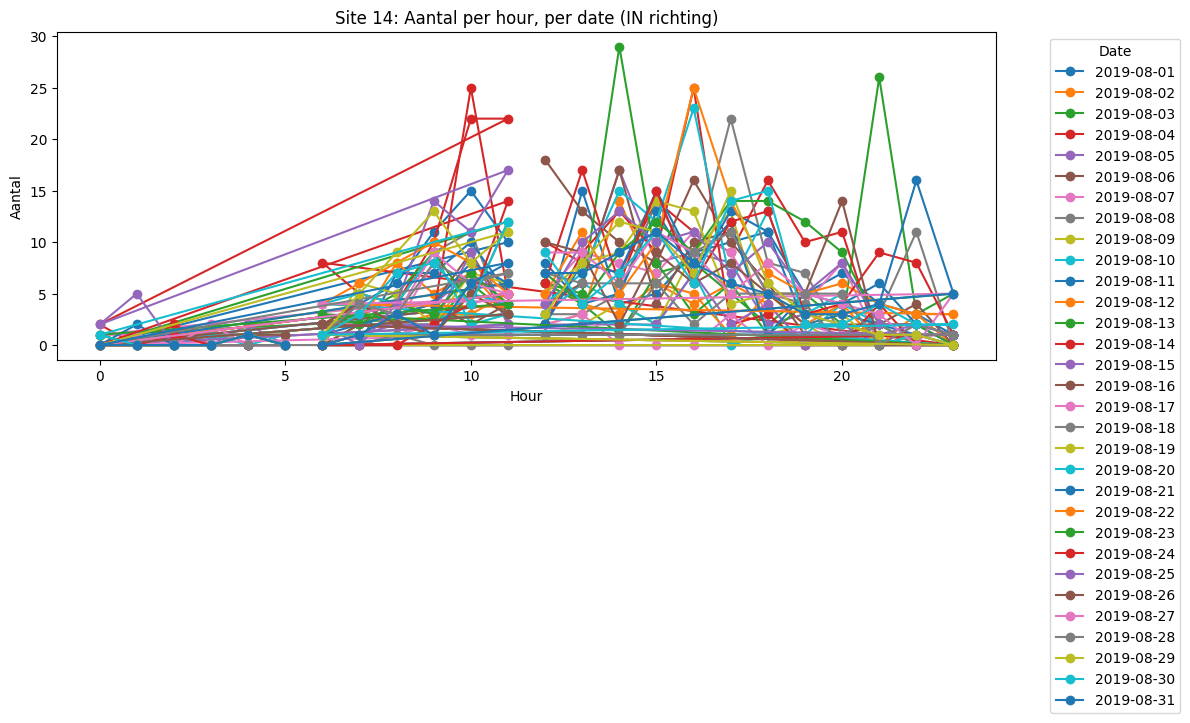

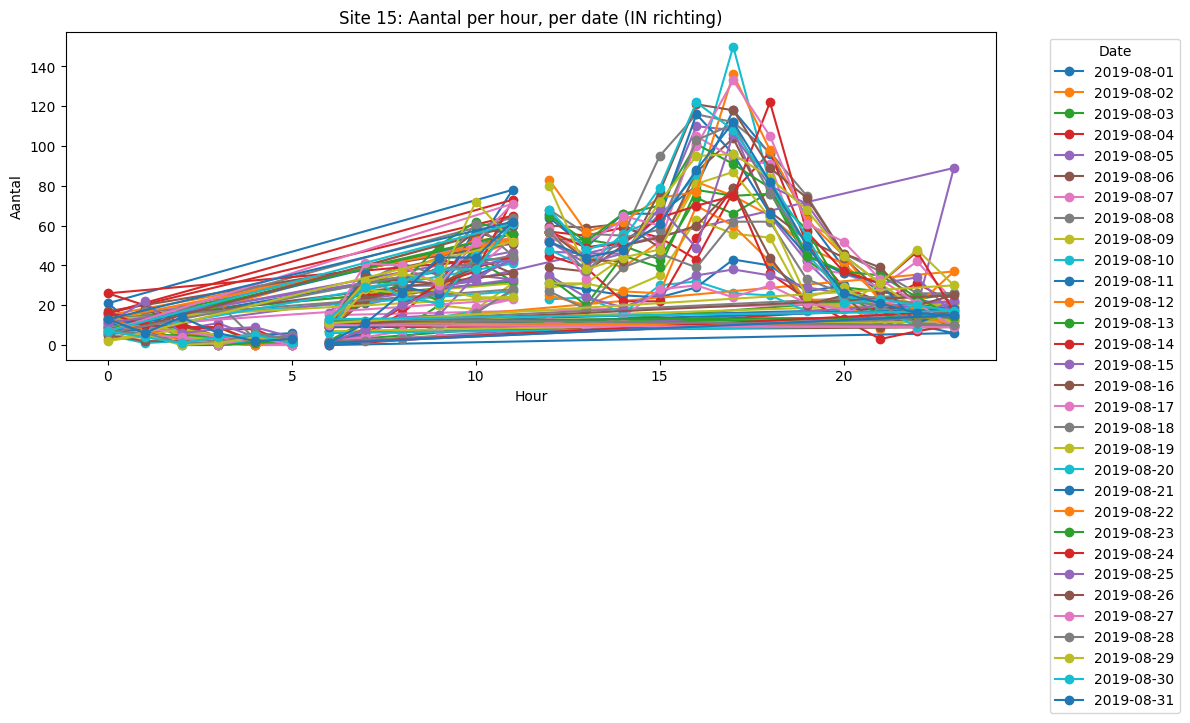

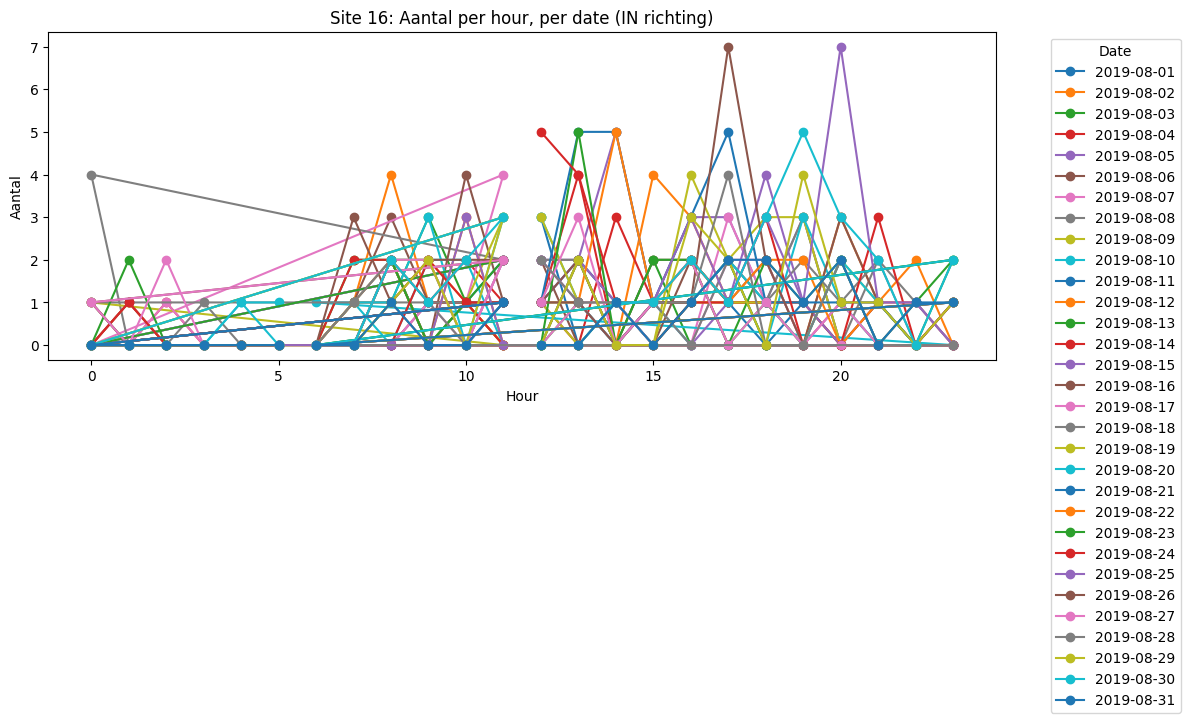

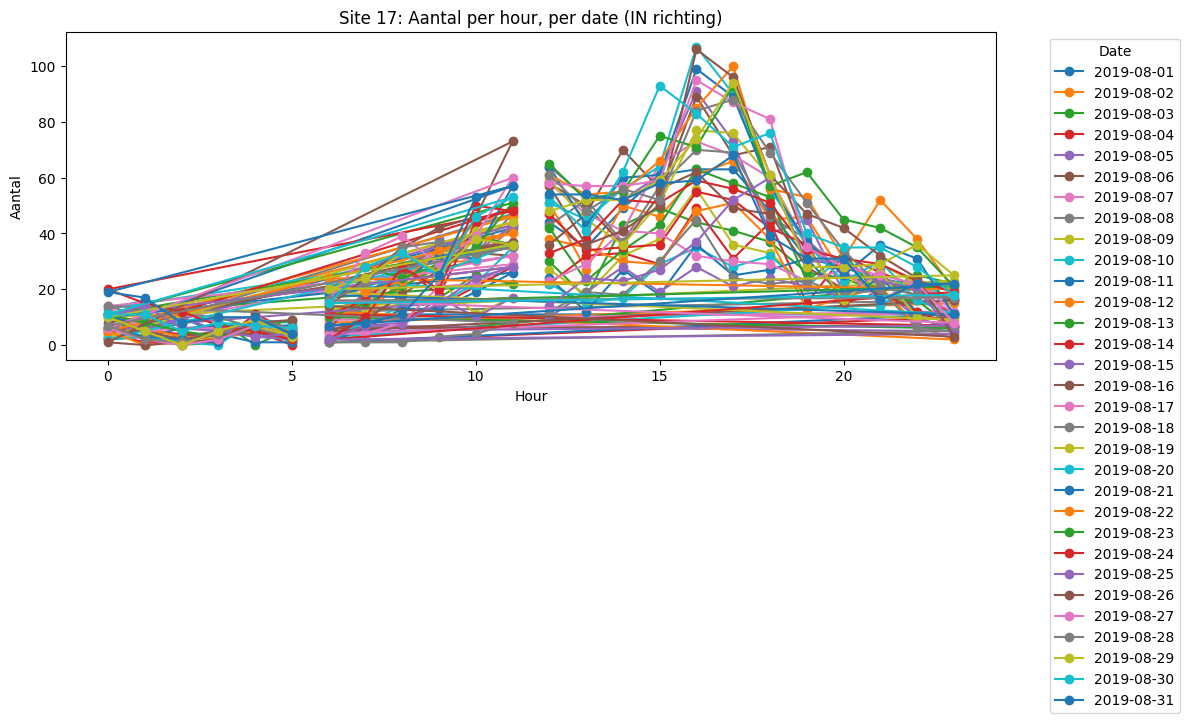

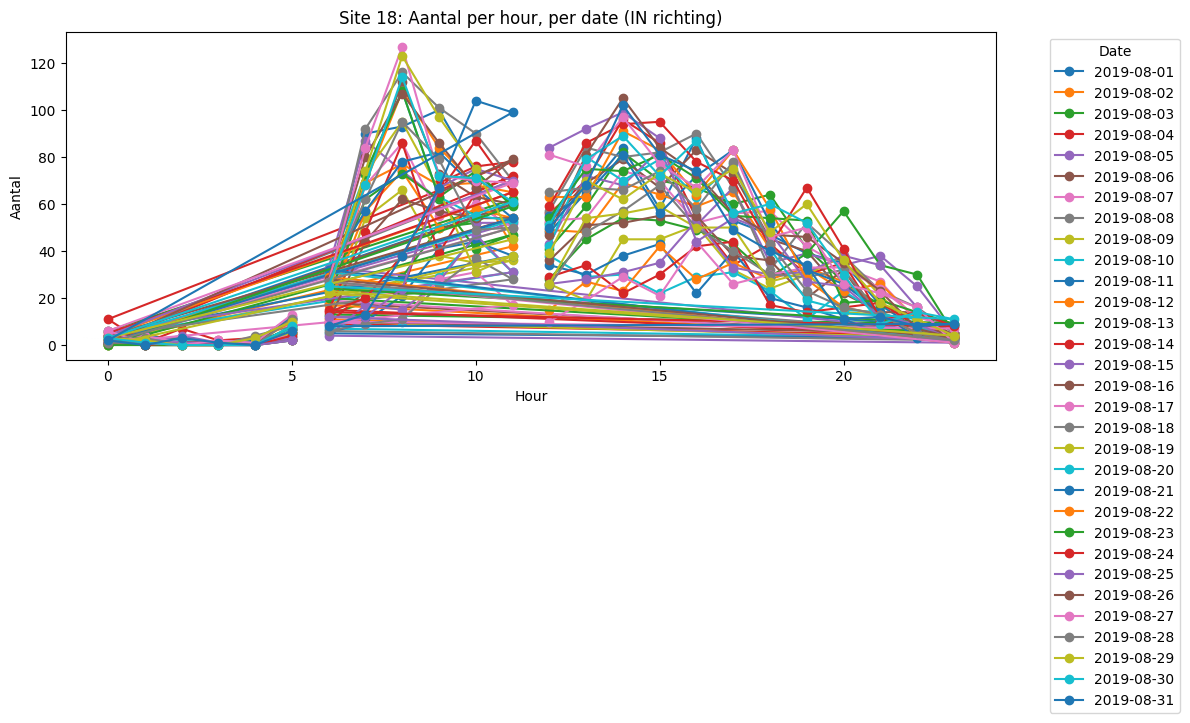

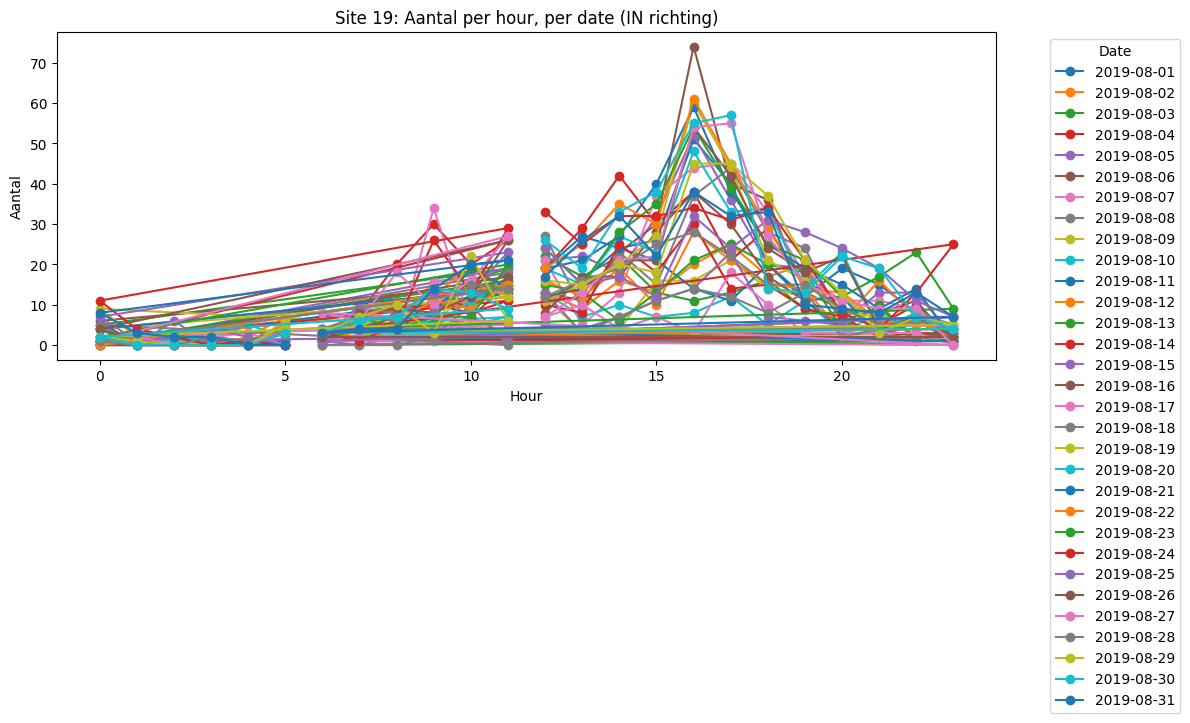

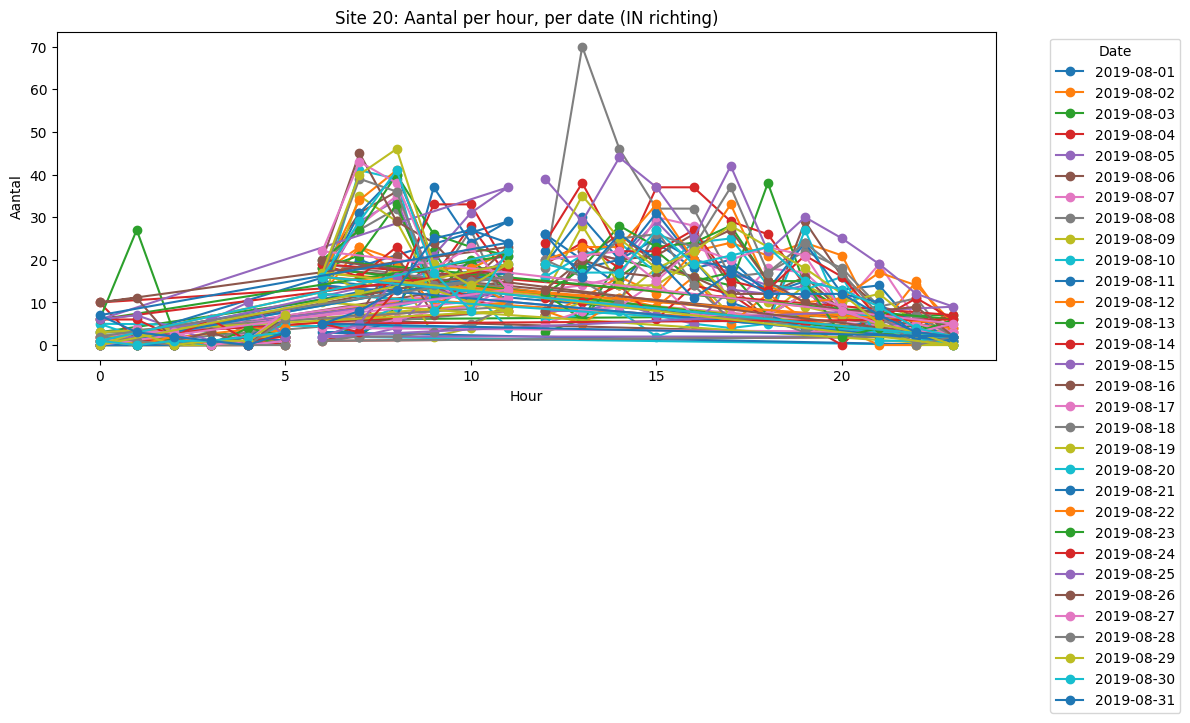

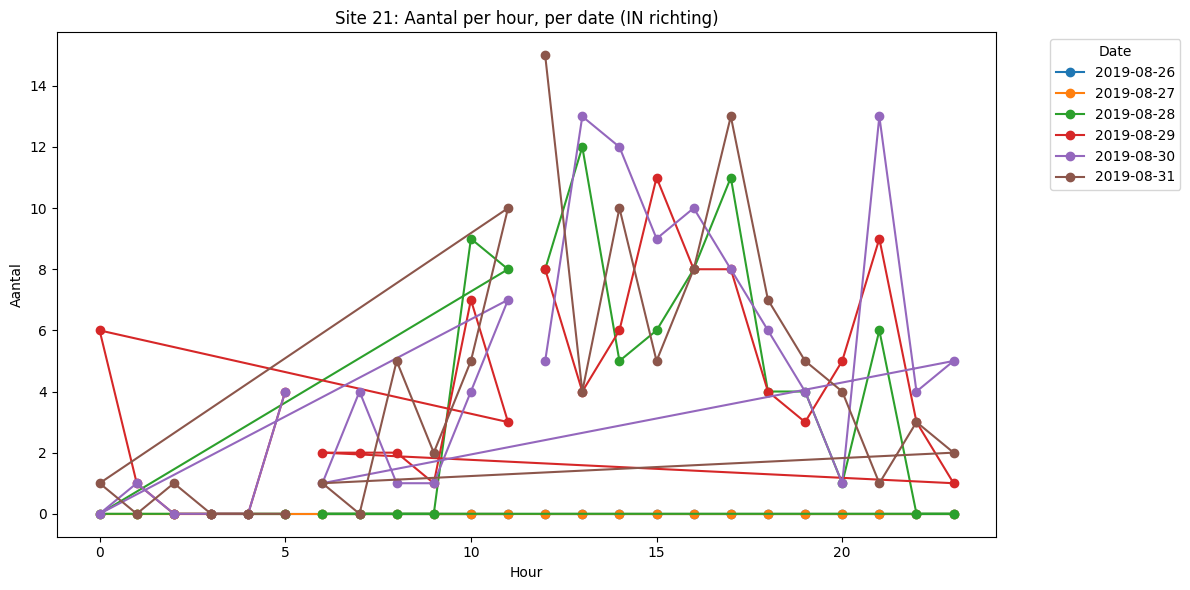

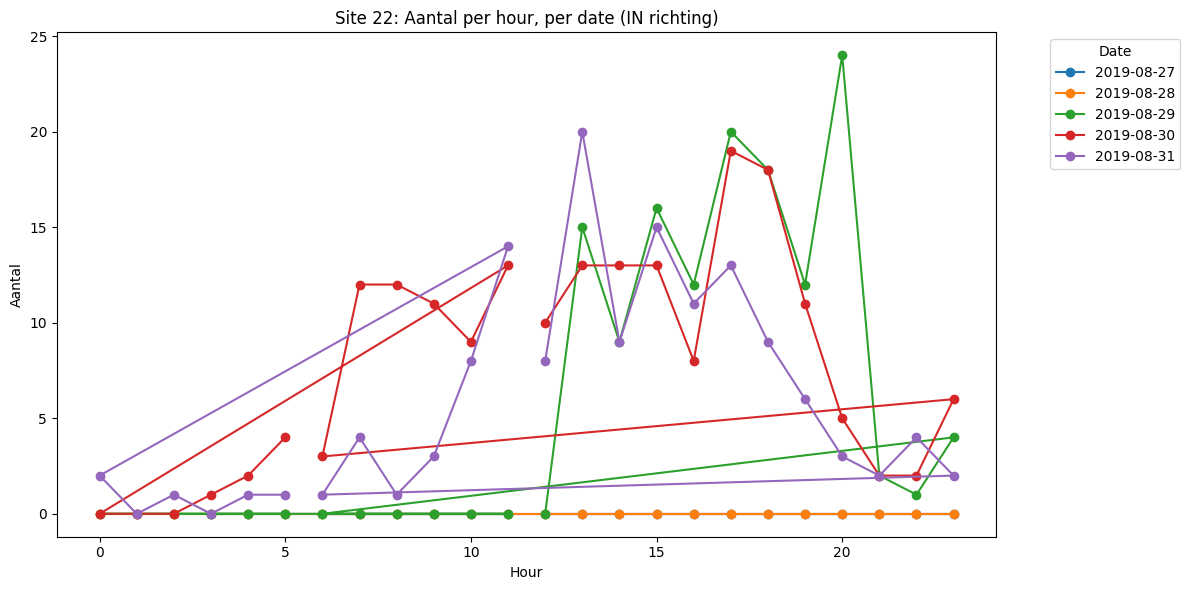

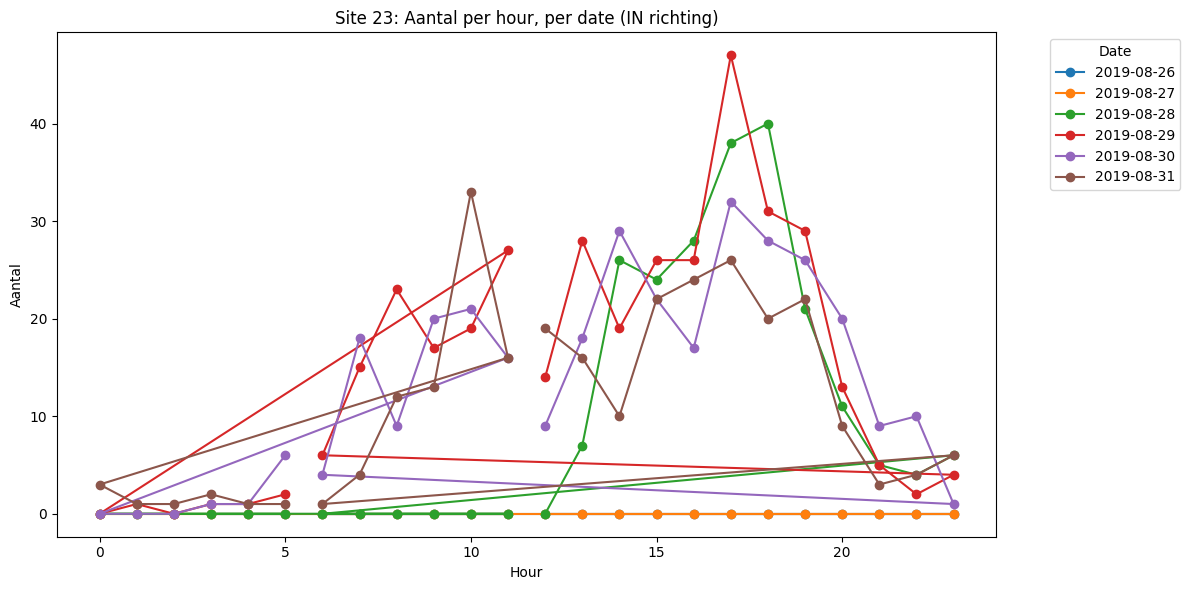

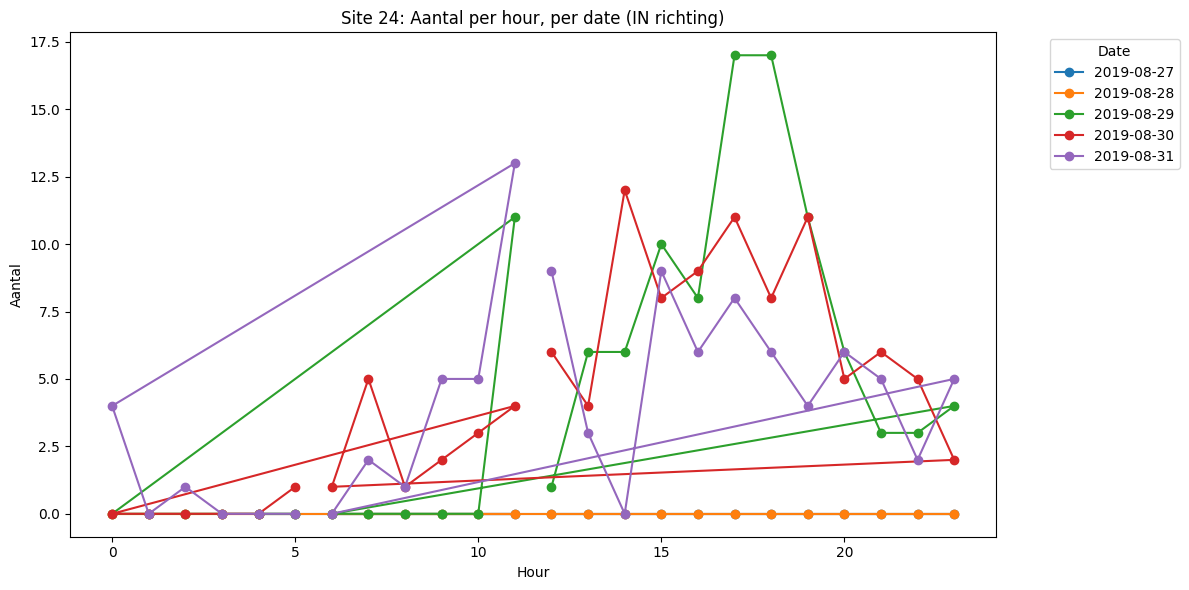

In [196]:
import matplotlib.pyplot as plt

# Filter data for IN direction only
df_in = dfx[dfx['richting'] == 'IN']

for site_id, group in df_in.groupby('siteid'):
    plt.figure(figsize=(12, 6))
    for date, subg in group.groupby('date'):
        plt.plot(subg['hour'], subg['aantal'], marker='o', label=str(date))
    plt.title(f'Site {site_id}: Aantal per hour, per date (IN richting)')
    plt.xlabel('Hour')
    plt.ylabel('Aantal')
    plt.legend(title='Date', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


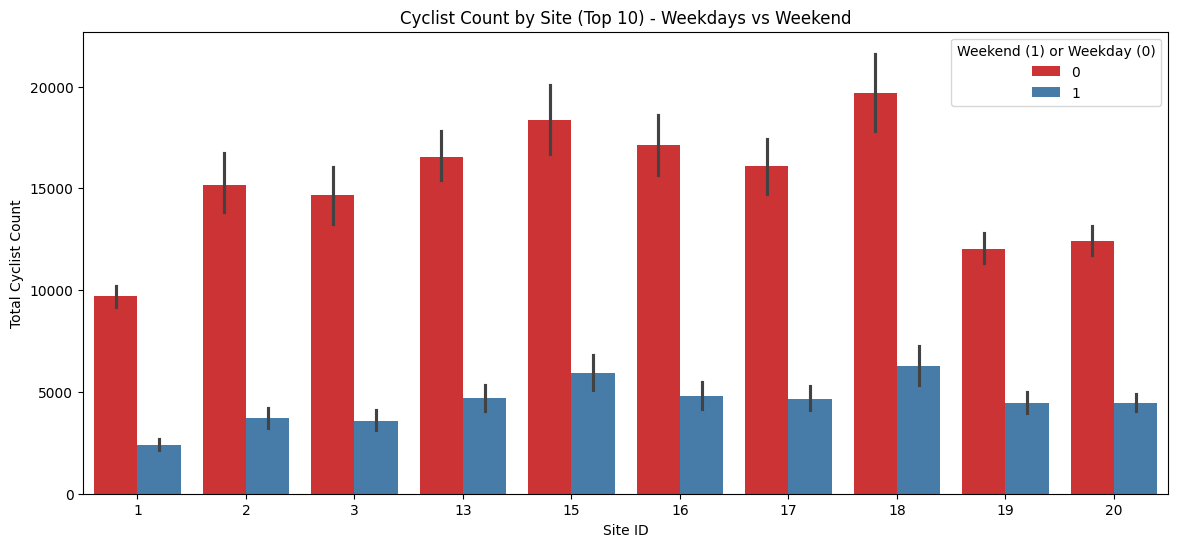

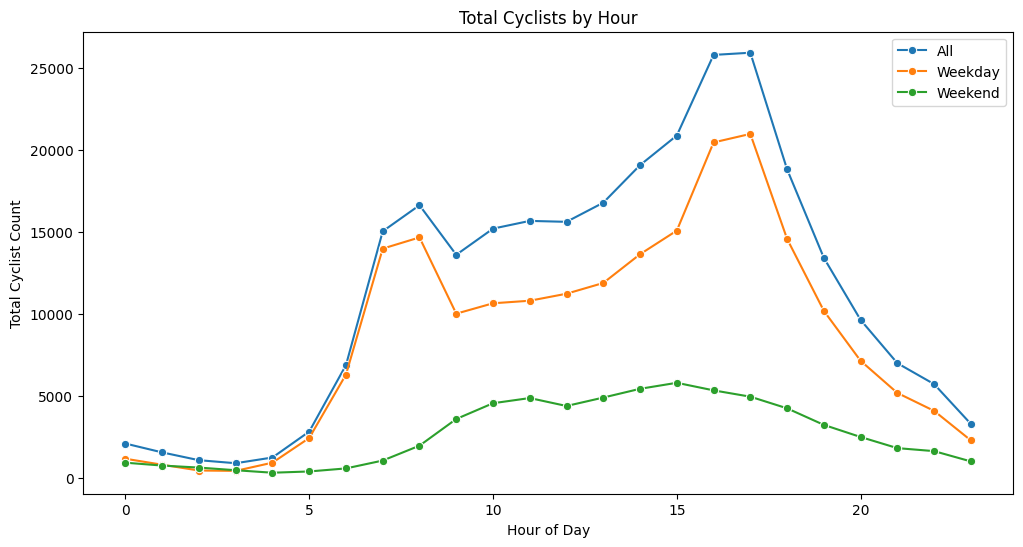

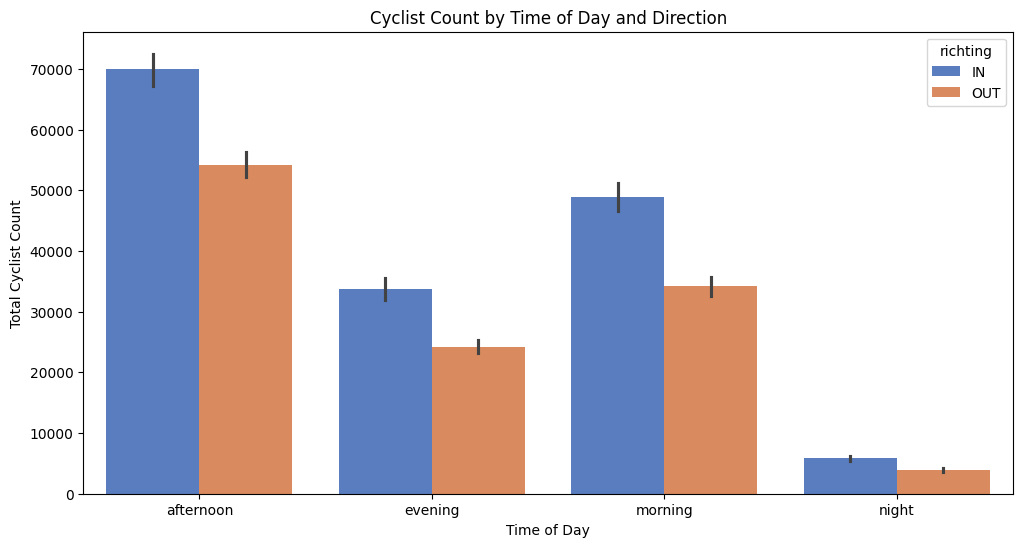

In [197]:
# 1. Total cyclist count per weekday vs weekend for top 10 sites
import seaborn as sns

top10_sites = dfx.groupby('siteid')['aantal'].sum().sort_values(ascending=False).head(10).index
df_top10 = dfx[dfx['siteid'].isin(top10_sites)]

plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_top10, 
    x='siteid', 
    y='aantal', 
    hue='weekend', 
    estimator=sum,
    hue_order=[0, 1],
    palette='Set1'
)
plt.title('Cyclist Count by Site (Top 10) - Weekdays vs Weekend')
plt.xlabel('Site ID')
plt.ylabel('Total Cyclist Count')
plt.legend(title='Weekend (1) or Weekday (0)')
plt.show()

# 2. Total count by hour (all, weekday, weekend)
plt.figure(figsize=(12, 6))
# All days
sns.lineplot(
    data=dfx.groupby('hour')['aantal'].sum().reset_index(), 
    x='hour', y='aantal', marker='o', label='All'
)
# Weekdays
sns.lineplot(
    data=dfx[dfx['weekend']==0].groupby('hour')['aantal'].sum().reset_index(),
    x='hour', y='aantal', marker='o', label='Weekday'
)
# Weekends
sns.lineplot(
    data=dfx[dfx['weekend']==1].groupby('hour')['aantal'].sum().reset_index(),
    x='hour', y='aantal', marker='o', label='Weekend'
)
plt.title('Total Cyclists by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Cyclist Count')
plt.legend()
plt.show()

# 3. Cyclist count by direction and tod (time of day)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=dfx, 
    x='tod', 
    y='aantal', 
    hue='richting', 
    estimator=sum,
    palette='muted'
)
plt.title('Cyclist Count by Time of Day and Direction')
plt.xlabel('Time of Day')
plt.ylabel('Total Cyclist Count')
plt.show()

**Additional data:**
- weather by date
- city: urban, rural, population density, city type 1/2/3?
- number of cyclist in each municipal
- event date

## B. Extra Data

In [74]:
df_counts = pd.read_csv(PATH_COUNT, header=None)
df_counts.columns=['site_id', 'richting', 'type', 'van', 'tot', 'aantal']

df_rich = pd.read_csv(PATH_RICH, header=None)
df_rich.columns=['siteid', 'richting', 'naam']

df_sites = pd.read_csv(PATH_SITES, header=None)
df_sites.columns = ['site_id', 'site_no', 'longtitude', 'latitude', 'name', 'domain', 'road_number', 'district', 'municipality', 'interval', 'install_date']

#### 1. Population density: by node (assume the same from 2019-2026)

In [ ]:
compute_site_population_buffers(
    df_sites, 
    raster_path="extra_data/bel_pop_2025_CN_100m_R2025A_v1.tif",
    rad_values=[1000, 5000, 10000],
    buffer_crs="EPSG:31370",
).to_csv('eda_data/site_pop.csv', index=False)

In [83]:
df_site_pop = pd.read_csv('eda_data/site_pop.csv')
df_site_pop.head()

,site_id,site_no,longtitude,latitude,geometry,pop_1km,pop_5km,pop_10km
0,1,100046096,4.456122,50.916183,POINT (4.456121776137429 50.91618331151478),2754.790527,99128.390625,726663.750000
1,2,100052862,4.471690,51.275120,POINT (4.47169 51.27512),1369.083008,165217.234375,590641.437500
2,3,100052863,4.472220,51.275030,POINT (4.47222 51.27503),1213.038208,165126.484375,590422.687500
3,4,100052864,5.190110,51.160230,POINT (5.19011 51.16023),851.324463,27176.691406,118754.562500
4,5,100052865,5.190030,51.160180,POINT (5.19003 51.16018),858.013428,27176.822266,118752.179688


#### 2. Weather: by date/ hour/ node

In [145]:
# df1 = pd.read_csv('extra_data/aws_1day_complete_2019_08.csv')
# df1.shape

In [286]:
df_weather.head(2)

,region,latitude,longtitude,datetime,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,Brussels,50.8503,4.3517,2019-08-01T00:00,15.9,74,0.0,0.0,0.0,13.0,214,1016.9,63
1,Brussels,50.8503,4.3517,2019-08-01T01:00,15.9,76,0.0,0.0,0.0,12.1,217,1017.1,56


In [214]:
df_weather = pd.read_csv("extra_data/belgium_weather_2019_2026.csv").rename(columns={'longitude':'longtitude'})
print(df_weather.shape)

gdf_weather = df2gdf(df_weather)
flander_boundary = gpd.read_file("extra_data/flander_boundary.geojson")
df_weather_flander = gpd.sjoin(gdf_weather, flander_boundary[['geometry']], predicate='within').drop(columns='index_right').reset_index(drop=True)
print(df_weather_flander.shape)
df_weather_flander['region'].unique()

(874800, 13)
(408240, 14)


array(['Antwerp', 'Ghent', 'Bruges', 'Leuven', 'Hasselt', 'Kortrijk',
       'Ostend'], dtype=object)

In [211]:
gdf_site_pop = df2gdf(df_site_pop)
gdf_weather_flander = df2gdf(df_weather_flander.rename(columns={'latitude':'latitude_wt','longtitude':'longtitude_wt'}), long_col='longtitude_wt', lat_col='latitude_wt')

df_weather_site_pop = gpd.sjoin_nearest(
    gdf_weather_flander, 
    gdf_site_pop, 
    how='left', 
    distance_col='distance'
).drop(columns=['latitude_wt','longtitude_wt','geometry','index_right'])
df_weather_site_pop.shape

/Users/ponddie/miniconda3/envs/llm_py312/lib/python3.12/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


(408240, 19)

In [212]:
df_weather_site_pop['date'] = df_weather['datetime'].apply(lambda x: str(x)[:10])
df_weather_site_pop['hour'] = df_weather['datetime'].apply(lambda x: int(str(x)[11:13]))

In [213]:
df_weather_site_pop.head(2)

,region,datetime,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover,site_id,site_no,longtitude,latitude,pop_1km,pop_5km,pop_10km,distance,date,hour
0,Antwerp,2019-08-01T00:00,16.1,72,0.0,0.0,0.0,12.8,212,1016.5,29,2,100052862,4.47169,51.27512,1369.083008,165217.234375,590641.4375,0.088837,2019-08-01,0
1,Antwerp,2019-08-01T01:00,16.1,75,0.0,0.0,0.0,12.2,208,1016.7,53,2,100052862,4.47169,51.27512,1369.083008,165217.234375,590641.4375,0.088837,2019-08-01,1


#### Population

In [165]:
df1 = pd.read_excel("extra_data/OPENDATA_MAP_2017-2024.xlsx")
df2 = pd.read_excel("extra_data/OPENDATA_SECTOREN_2025_NEW.xlsx")
df3 = pd.read_excel("extra_data/Pop_density_en.xlsx")
df1.shape, df2.shape, df3.shape

((289532, 45), (21183, 10), (639, 6))

In [166]:
df_struct = pd.read_excel("extra_data/TF_SOC_POP_STRUCT_2025.xlsx")
df_ve = pd.read_excel("extra_data/TF_VEHICLES_COLLISION_2024.xlsx")
df_struct.shape, df_ve.shape

((466822, 21), (43646, 63))

In [167]:
display(df1.head(2))
display(df2.head(2))
display(df3.head(2))

,DT_YEAR_COLLISION,DT_MONTH_COLLISION,DT_TIME,CD_NIS,TX_RGN_COLLISION_FR,TX_RGN_COLLISION_NL,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_MUNTY_COLLISION_FR,TX_MUNTY_COLLISION_NL,MS_X_COORD,MS_Y_COORD,CD_CROSSWAY,TX_CROSSWAY_FR,TX_CROSSWAY_NL,CD_WEATHER,TX_WEATHER_FR,TX_WEATHER_NL,CD_ROAD_CONDITION,TX_ROAD_CONDITION_FR,TX_ROAD_CONDITION_NL,CD_BUILD_UP_AREA,TX_BUILD_UP_AREA_FR,TX_BUILD_UP_AREA_NL,CD_LIGHT_CONDITION,TX_LIGHT_CONDITION_FR,TX_LIGHT_CONDITION_NL,CD_ROAD_TYPE,CD_ROAD_TYPE_FR,CD_ROAD_TYPE_NL,CD_CLASS_ACCIDENTS,TX_CLASS_ACCIDENTS_FR,TX_CLASS_ACCIDENTS_NL,CD_ROAD_USR_TYPE1,TX_ROAD_USR_TYPE1_FR,TX_ROAD_USR_TYPE1_NL,CD_ROAD_USR_TYPE2,TX_ROAD_USR_TYPE2_FR,TX_ROAD_USR_TYPE2_NL,CD_COLLISION_TYPE,TX_COLLISON_TYPE_FR,TX_COLLISION_TYPE_NL,CD_OBSTACLES,TX_OBSTACLES_FR,TX_OBSTACLES_NL
0,2017,1,1,21015,Région de Bruxelles-Capitale,Brussels Hoofdstedelijk Gewest,NaN,NaN,Schaerbeek,Schaarbeek,149732.990,172425.510,1,Carrefour,Op Kruispunt,1,Normales,Normaal,1,Sec,Droog,1,En agglomération,binnen bebouwde kom,3,"Nuit, éclairage public présent et allumé","Nacht, openbare verlichting aanwezig en ontstoken",2,Route communale,Gemeenteweg,4,Avec blessé(s) leger(s),met lichtgewonden,9,Voiture,personenauto,8,Piéton,Voetganger,5,Avec un piéton,Met een voetganger,0,Pas d’obstacle,Geen hindernis
1,2017,1,0,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,152268.069,209633.121,1,Carrefour,Op Kruispunt,1,Normales,Normaal,1,Sec,Droog,1,En agglomération,binnen bebouwde kom,3,"Nuit, éclairage public présent et allumé","Nacht, openbare verlichting aanwezig en ontstoken",2,Route communale,Gemeenteweg,4,Avec blessé(s) leger(s),met lichtgewonden,3,Bicyclette,Fiets,9,Voiture,personenauto,2,Entre 2 conducteurs: Collision frontale,Tussen 2 bestuurders: Frontale botsing,0,Pas d’obstacle,Geen hindernis


,CD_REFNIS,CD_SECTOR,TOTAL,DT_STRT_SECTOR,DT_STOP_SECTOR,OPPERVLAKKTE IN HM²,TX_DESCR_SECTOR_NL,TX_DESCR_SECTOR_FR,TX_DESCR_NL,TX_DESCR_FR
0,11001,11001A00-,2618,1981-03-01,9999-12-31 00:00:00,52.987652,AARTSELAAR-CENTRUM,AARTSELAAR-CENTRUM,Aartselaar,Aartselaar
1,11001,11001A01-,2922,1981-03-01,9999-12-31 00:00:00,67.244078,DE LEEUWERIK,DE LEEUWERIK,Aartselaar,Aartselaar


,Population density by municipality 1st January 2019,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Refnis,Municipality FR,Municipality NL,Population,Size in km²,Population / km²
1,01000,Belgique,België,11431406,30689.368862,372.487491


In [168]:
display(df_struct.head(2))
display(df_ve.head(2))

,CD_REFNIS,TX_DESCR_NL,TX_DESCR_FR,CD_DSTR_REFNIS,TX_ADM_DSTR_DESCR_NL,TX_ADM_DSTR_DESCR_FR,CD_PROV_REFNIS,TX_PROV_DESCR_NL,TX_PROV_DESCR_FR,CD_RGN_REFNIS,TX_RGN_DESCR_NL,TX_RGN_DESCR_FR,CD_SEX,CD_NATLTY,TX_NATLTY_NL,TX_NATLTY_FR,CD_CIV_STS,TX_CIV_STS_NL,TX_CIV_STS_FR,CD_AGE,MS_POPULATION
0,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,67,14
1,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,93,1


,DT_YEAR_COLLISION,DT_MONTH_COLLISION,TX_MONTH_COLLISION_FR,TX_MONTH_COLLISION_NL,CD_DAY_NIGHT,TX_DAY_NIGHT_FR,TX_DAY_NIGHT_NL,FL_WEEKEND,CD_VEHICLE_SEGMENT_A,TX_VEHICLE_SEGMENT_A_FR,TX_VEHICLE_SEGMENT_A_NL,CD_VEHICLE_SEGMENT_B,TX_VEHICLE_SEGMENT_B_FR,TX_VEHICLE_SEGMENT_B_NL,MS_VEHICLE_AGE_AT_COLLISION_YR,TX_VEHICLE_CLASS_AGE_AT_COLL_YR,CD_FUEL_TYPE,TX_FUEL_TYPE_FR,TX_FUEL_TYPE_NL,CD_CYLINDER_CLASS_A,TX_CYLINDER_CLASS_A,CD_CYLINDER_CLASS_B,TX_CYLINDER_CLASS_B,CD_OWNER_TYPE,TX_OWNER_TYPE_FR,TX_OWNER_TYPE_NL,FL_VEHICLE,FL_CITY_CAR,FL_COMPACT_CAR,FL_BERLINE,FL_SUV,FL_MONOSPACE,FL_PICK_UP,FL_TRUCK_BUS,FL_MOTO_CYCLO,FL_SPORT,FL_UKN,CD_PROV_COLLISION,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_REGION_COLLISON_FR,TX_REGION_COLLISON_NL,CD_WEATHER,TX_WEATHER_FR,TX_WEATHER_NL,CD_ROAD_CONDITION,TX_ROAD_CONDITION_FR,TX_ROAD_CONDITION_NL,CD_BUILD_UP_AREA,TX_BUILD_UP_AREA_FR,TX_BUILD_UP_AREA_NL,CD_LIGHT_CONDITION,TX_LIGHT_CONDITION_FR,TX_LIGHT_CONDITION_NL,CD_ROAD_TYPE,TX_ROAD_TYPE_FR,TX_ROAD_TYPE_NL,CD_ACCIDENT_CLASS,TX_ACCIDENT_CLASS_FR,TX_ACCIDENT_CLASS_NL,CD_COLLISION_TYPE,TX_COLLISON_TYPE_FR,TX_COLLISON_TYPE_NL
0,2024,1,janvier,januari,1,jour,dag,N,D,Berlines familiales (Taille S),Familie sedans (maat S),3,Berlines,sedans,6,5-9,2,GASOIL,DIESEL,2,1400<2000,4,1300<1600,1,Particulier,Particulier,1,0,0,1,0,0,0,0,0,0,0,50000,Province de Hainaut,Provincie Henegouwen,Région wallonne,Waals Gewest,1,Normales,Normaal,4,Propre,Proper,1,agglomération,Binnen bebouwde kom,1,Jour,Dag,2,route regionale,gewestweg,3,Avec blessé(s) leger(s),met lichtgewonden,A,Entre 2 conducteurs: Flanc contre flanc,Tussen 2 bestuurders: Flank tegen flank
1,2024,1,janvier,januari,1,jour,dag,N,B,Citadines / polyvalentes ou sous-compactes,Stadsauto's / veelzijdig of subcompact,1,Urbaines et citadines,Stadswagens,7,5-9,1,ESSENCE,BENZINE,1,0<1400,3,1100<1300,1,Particulier,Particulier,1,1,0,0,0,0,0,0,0,0,0,50000,Province de Hainaut,Provincie Henegouwen,Région wallonne,Waals Gewest,1,Normales,Normaal,4,Propre,Proper,1,agglomération,Binnen bebouwde kom,1,Jour,Dag,2,route regionale,gewestweg,3,Avec blessé(s) leger(s),met lichtgewonden,A,Entre 2 conducteurs: Flanc contre flanc,Tussen 2 bestuurders: Flank tegen flank


In [170]:
df_ve['TX_MONTH_COLLISION_NL'].unique()

array(['januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli',
       'augustus', 'september', 'oktober', 'november', 'december'],
      dtype=object)

In [206]:
flander_office = gpd.read_file("extra_data/flander_office.geojson")

In [217]:
flander_cycling_route = gpd.read_file("extra_data/flander_cycling_route.geojson")


In [253]:
pd.options.display.max_colwidth=50

In [277]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point

# 1. Setup your initial data
data = {
    'id': [1, 2, 3, 4],
    'lat': [50.8798, 51.0543, 50.4674, 51.2194], # Leuven, Ghent, Namur (Wallonia), Antwerp
    'lon': [4.7005, 3.7174, 4.8712, 4.4025]
}
df = pd.DataFrame(data)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)

# 2. Get Flanders Boundary (Region)
# admin_level 4 = Regions in Belgium
flanders_poly = ox.geocode_to_gdf("Vlaanderen, Belgium")

# 3. Get all City/Municipality Boundaries in Flanders
# admin_level 8 = Municipalities in Belgium
cities_gdf = ox.features_from_place("Vlaanderen, Belgium", tags={"admin_level": "8"})

# Clean up the cities GeoDataFrame to keep only names and geometry
cities_gdf = cities_gdf[cities_gdf["boundary"] == "administrative"][["name", "geometry"]]

# 4. Filter: Keep only points inside Flanders
gdf_flanders = gpd.sjoin(gdf, flanders_poly, predicate='within')
# Drop extra columns from the join
gdf_flanders = gdf_flanders[df.columns.tolist() + ['geometry']]

# 5. Assign City Names: Spatial Join with the cities_gdf
# This tells us WHICH city each point is in
final_df = gpd.sjoin(gdf_flanders, cities_gdf, how="left", predicate="within")

# Result Cleanup
final_df = final_df.rename(columns={'name': 'city_name'})
print(final_df[['id', 'lat', 'lon', 'city_name']])

KeyboardInterrupt: 

In [ ]:
final_df.head()

In [ ]:
import requests
import pandas as pd

overpass_url = "http://overpass-api.de/api/interpreter"
overpass_query = """
[out:json];
area["name"="Vlaanderen"]["admin_level"="4"]->.flanders;
(
  node["place"~"city|town"](area.flanders);
);
out body;
"""

response = requests.get(overpass_url, params={'data': overpass_query})
data = response.json()

# Extract name, lat, and lon into a list
cities = []
for element in data['elements']:
    cities.append({
        'name': element.get('tags', {}).get('name'),
        'lat': element.get('lat'),
        'lon': element.get('lon'),
        'type': element.get('tags', {}).get('place')
    })

df_cities = pd.DataFrame(cities)

In [276]:
gdf_cities

,name,lat,lon,type,geometry


In [270]:
df_towns.query('type=="city"')

,name,lat,lon,type


In [265]:
flander_boundary = gpd.read_file("extra_data/flander_boundary.geojson")
flander_boundary.head()

,id,@id,@relations,ISO3166-2,admin_level,alt_name:ur,border_type,boundary,default_language,flag,name,name:ar,name:bg,name:br,name:ca,name:cy,name:de,name:el,name:en,name:eo,name:es,name:et,name:fi,name:fr,name:fy,name:ga,name:gd,name:gv,name:hu,name:ja,name:ka,name:ko,name:kw,name:lb,name:li,name:lt,name:nl,name:pcd,name:pl,name:pt,name:ro,name:ru,name:sk,name:th,name:tzl,name:uk,name:ur,name:vls,name:wa,name:zh,name:zh-Hans,name:zh-Hant,nat_name,nat_name:ar,nat_name:be,nat_name:bg,nat_name:ca,nat_name:de,nat_name:el,nat_name:en,nat_name:eo,nat_name:es,nat_name:fr,nat_name:fy,nat_name:lb,nat_name:li,nat_name:mk,nat_name:nl,nat_name:os,nat_name:pcd,nat_name:pl,nat_name:ru,nat_name:sk,nat_name:tr,nat_name:vls,nat_name:wa,ref:INS,ref:nuts:1,source:name:br,type,website,wikidata,wikipedia,geometry
0,relation/53134,relation/53134,None,BE-VLG,4,ولاندرن,state,administrative,nl,File:Flag_of_Flanders.svg,Vlaanderen,فلاندر,Фландрия,Flandrez,Flandes,Fflandrys,Flandern,Φλάνδρα,Flanders,Flandrio,Flandes,Flandria,Flanderi,Flandre,Flaanderen,Flóndras,Flànras,Yn Flandyryn,Flandria,フランデレン地域,ფლანდრია,플라망 지역,Pow Flamanek,Flandern,Vlaondere,Flandrija,Vlaanderen,Flande,Flandria,Flandres,Flandra,Фландрия,Flámsko,เขตฟลามส์,Flemphäts,Фландрія,فلاندرن,Vloandern,Flande,弗拉芒大區,弗拉芒大区,弗拉芒大區,Vlaams Gewest,الإقليم الفلامندي,Фламандскі рэгіён,Фламандски регион,Regió flamenca,Flämische Region,Φλαμανδική Περιοχή,Flemish Region,Flandra Regiono,Región Flamenca,Région flamande,Flaamsk Gewest,Flämesch Regioun,Vlaondere Gewes,Фламански регион,Vlaams Gewest,Фламандийы регион,Région flaminke,Region Flamandzki,Фламандский регион,Flámsky región,Flaman Bölgesi,Vlams Gewest,Redjon flaminde,02000,BE2,ofis publik ar brezhoneg,boundary,https://www.vlaanderen.be/,Q9337,nl:Vlaams Gewest,"MULTIPOLYGON (((4.93987 51.43949, 4.94153 51.4..."
1,node/1635651356,node/1635651356,"[{'role': 'admin_centre', 'rel': 53134, 'relta...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,POINT (4.35249 50.84674)
2,node/2703796567,node/2703796567,"[{'role': 'label', 'rel': 53134, 'reltags': {'...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,POINT (4.24056 51.03778)


In [281]:
df = pd.read_csv('extra_data/cycling_accidents_aug2019.csv')

In [282]:
df.head()

,year,month,hour,municipality_fr,municipality_nl,province_fr,region_fr,latitude,longitude,nis_code,weather_fr,weather_nl,road_condition_fr,road_condition_nl,light_condition_fr,build_up_area_fr,road_type_fr,severity_fr,road_user1_fr,road_user2_fr,collision_type_fr,at_crossway
0,2019,8,14,Anvers,Antwerpen,Province d’Anvers,Région flamande,51.199960,4.436284,11002,Normales,Normaal,Sec,Droog,Jour,Hors agglomération,Autoroute,Avec blessé(s) leger(s),Motocyclette,Voiture,Entre 2 conducteurs: Flanc contre flanc,0
1,2019,8,18,Machelen,Machelen,Province du Brabant flamand,Région flamande,50.907847,4.448908,23047,Normales,Normaal,Sec,Droog,Jour,Hors agglomération,Autoroute,Avec blessé(s) leger(s),Motocyclette,Camion,Entre 2 conducteurs: Par l'arrière,0
2,2019,8,17,Hoeilaart,Hoeilaart,Province du Brabant flamand,Région flamande,50.761582,4.439201,23033,Normales,Normaal,Sec,Droog,Jour,Hors agglomération,Autoroute,Avec blessé(s) leger(s),Motocyclette,Voiture,Entre 2 conducteurs: Par l'arrière,0
3,2019,8,21,Charleroi,Charleroi,Province de Hainaut,Région wallonne,50.403946,4.366098,52011,Normales,Normaal,Sec,Droog,Jour,Hors agglomération,Route régionale,Avec blessé(s) leger(s),Voiture,Motocyclette,Entre 2 conducteurs: Flanc contre flanc,0
4,2019,8,18,Forest,Vorst,NaN,Région de Bruxelles-Capitale,50.821389,4.342135,21007,Normales,Normaal,Propre,Proper,Jour,En agglomération,Route régionale,Avec blessé(s) leger(s),Voiture,Motocyclette,Entre 2 conducteurs: Par le côté (avant/derriè...,1


In [285]:
df[df['road_user2_fr']=='Bicyclette'].head()

,year,month,hour,municipality_fr,municipality_nl,province_fr,region_fr,latitude,longitude,nis_code,weather_fr,weather_nl,road_condition_fr,road_condition_nl,light_condition_fr,build_up_area_fr,road_type_fr,severity_fr,road_user1_fr,road_user2_fr,collision_type_fr,at_crossway
7,2019,8,22,Bruxelles,Brussel,NaN,Région de Bruxelles-Capitale,NaN,NaN,21004,"Inconnues, indéterminées",Onbekend,"Inconnu, indéterminé",Onbekend,"Aube, crépuscule",En agglomération,Route communale,Avec blessé(s) leger(s),Voiture,Bicyclette,Entre 2 conducteurs: Par le côté (avant/derriè...,0
9,2019,8,17,Saint-Gilles,Sint-Gillis,NaN,Région de Bruxelles-Capitale,50.832752,4.342901,21013,Normales,Normaal,Propre,Proper,Jour,En agglomération,Route communale,Avec blessé(s) leger(s),Voiture,Bicyclette,Entre 2 conducteurs: Flanc contre flanc,1
10,2019,8,15,Anderlecht,Anderlecht,NaN,Région de Bruxelles-Capitale,50.844160,4.333811,21001,"Autre (fumée épaisse,...)","Andere (dikke rook,...)",Propre,Proper,Jour,En agglomération,Route communale,Avec blessé(s) leger(s),Voiture,Bicyclette,Entre 2 conducteurs: Par le côté (avant/derriè...,0
14,2019,8,20,Anderlecht,Anderlecht,NaN,Région de Bruxelles-Capitale,50.836932,4.324760,21001,Normales,Normaal,Sec,Droog,Jour,En agglomération,Route communale,Avec blessé(s) leger(s),Voiture,Bicyclette,Entre 2 conducteurs: Par le côté (avant/derriè...,0
22,2019,8,12,Aartselaar,Aartselaar,Province d’Anvers,Région flamande,51.133393,4.377041,11001,Normales,Normaal,Sec,Droog,Jour,Hors agglomération,Route communale,Avec blessé(s) leger(s),Voiture,Bicyclette,Entre 2 conducteurs: Flanc contre flanc,1
